# Исследование линейных моделей для решения задачи линейной регрессии

Изучим особенности построения линейных моделей для решения задачи линейной регрессии на примере набора данных о добыче газа.

**Описание признаков**

| Признак                | Описание                        |
| ---------------------- | ------------------------------- |
| `well_id`              | идентификатор скважины          |
| `porosity`             | пористость скважины             |
| `permeability`         | проницаемость скважины          |
| `acoustic_impedance`   | акустический импеданс           |
| `brittleness`          | коэффициент хрупкости скважины  |
| `organic_carbon`       | общий органический углерод      |
| `vitrinite_reflectance`| коэффициент отражения витринита |

**Целевая переменная**

`extr_per_day` — добыча газа в сутки (млн кубических футов).


In [1]:
# Импорт нужных библиотек и моделей,
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro

from sklearn import (
    model_selection,
    linear_model, preprocessing,
    metrics
)

In [2]:
# Читаем данные
well_df = pd.read_csv('well_data.csv')

## EDA

Проанализируем основную информацию о датафрейме: количество строк, столбцов, типы данных, наличие пропусков и полных дубликатов, а также выведем первые нескольок строк.

In [3]:
def df_info(df, df_name=None):
    """
    Выводит информацию о датафрейме.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки.
        df_name (str): Название датафрейма (для отображения).
    """

    # Шапка вывода
    print(
        '-' * 10,
        '' * 5,
        f'Информация о датафрейме {str(df_name)}: ',
        '' * 5,
        '-' * 10
    )
    print()

    # 1. Количество строк
    row_count = df.shape[0]
    print(f'1) Количество строк: {row_count}')

    # 2. Количество столбцов
    column_count = df.shape[1]
    print(f'2) Количество столбцов: {column_count}')

    # 3. Типы данных
    columns = df.dtypes
    print('3) Типы данных:')
    print()
    print(columns)
    print()

    # 4. Доля пропусков
    is_null = df.isna().mean() * 100
    print('4) Доля пропусков в каждом из столбцов:')
    print()
    print(is_null)
    print()

    # 5. Дубликаты
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = duplicate_count / len(df) * 100
    print(
        f'5) Полных дубликатов: {duplicate_count} '
        f'({duplicate_percentage:.2f}%)'
    )

In [4]:
df_info(well_df,"well_df")

display(well_df.head())

----------  Информация о датафрейме well_df:   ----------

1) Количество строк: 200
2) Количество столбцов: 8
3) Типы данных:

well_id                    int64
porosity                 float64
permeability             float64
acoustic_impedance       float64
brittleness              float64
organic_carbon           float64
vitrinite_reflectance    float64
extr_per_day             float64
dtype: object

4) Доля пропусков в каждом из столбцов:

well_id                  0.0
porosity                 0.0
permeability             0.0
acoustic_impedance       0.0
brittleness              0.0
organic_carbon           0.0
vitrinite_reflectance    0.0
extr_per_day             0.0
dtype: float64

5) Полных дубликатов: 0 (0.00%)


,well_id,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


Структура датафрейма соответствует заявленной в данных. Пропусков нет, полные дубликаты также отсутствуют. Нелишним будет проверить датафрейм на наличие неявных дубликатов (по всем полям кроме `well_id`).

In [5]:
# Список столбцов для проверки
cols_to_check = well_df.columns.drop('well_id')

hidden_duplicates = well_df.duplicated(subset=cols_to_check).sum()
print(f"Количество неявных дубликатов: {hidden_duplicates}")

Количество неявных дубликатов: 0


Неявные дубликаты отсутствуют. Так как все признаки являются числовыми, можем применить понижение разрядности для оптимизации.

In [6]:
def downcast(df):
    """
    Выполняет понижение разрядности числовых столбцов датафрейма
    с типами int64 и float64 для экономии памяти.
    Преобразует int64 к int8/int16/int32 и float64 к float32.

    Параметры:
        df (pandas.DataFrame): Датафрейм для обработки.

    Возвращает:
        pandas.DataFrame: Обработанный датафрейм с пониженной
        разрядностью числовых столбцов.

    Примечания:
        - Изменяет исходный датафрейм
        - Выводит информацию о датафрейме после преобразования
    """
    for dtype, column in zip(df.dtypes, df.columns):
        if dtype == 'int64':
            df[column] = pd.to_numeric(df[column], downcast='integer')
        elif dtype == 'float64':
            df[column] = pd.to_numeric(df[column], downcast='float')

    print('Результат понижения разрядности:')
    print()
    return df.info()

In [7]:
downcast(well_df)

Результат понижения разрядности:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                200 non-null    int16  
 1   porosity               200 non-null    float32
 2   permeability           200 non-null    float32
 3   acoustic_impedance     200 non-null    float32
 4   brittleness            200 non-null    float32
 5   organic_carbon         200 non-null    float32
 6   vitrinite_reflectance  200 non-null    float32
 7   extr_per_day           200 non-null    float32
dtypes: float32(7), int16(1)
memory usage: 6.0 KB


Признак `well_id` является неиформативным, так как описывает порядковый номер наблюдения в датасете. Можем удалить его без ущерба для дальнейшего анализа и построения модели.

In [8]:
# Удаляем столбец well_id
well_df = well_df.drop(columns=['well_id'])

Теперь изучим распределение признаков для того, чтобы проверить их на наличие выбросов.
Для этого применим оценку через `describe()`, визуальную оценку через `boxplot()`, а также `IQR` для статистической проверки.

In [9]:
well_df.describe()

,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,14.991150,4.330750,2.968850,48.161953,0.990450,1.964300,4311.220215
std,2.971176,1.731014,0.566885,14.129457,0.481588,0.300827,992.038452
min,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139404
25%,12.912500,3.122500,2.547500,37.754999,0.617500,1.770000,3618.064392
50%,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687256
75%,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089722
max,23.549999,9.870000,4.630000,84.330002,2.180000,2.870000,6662.622559


Минимальное значение по признаку `organic_carbon` отрицательное, что указывает на ошибку. Общий органический углерод (или TOC) это мера массы углерода, содержащегося в горной породе. Скорее всего появление отрицательного значения по данному признаку связано с ошибкой измерения.

Проверим, встречаются ли еще отрицательные значения по данному признаку и в каком количестве.

In [10]:
# Рассчитываем количество отрицательных наблюдений
negative_toc = well_df[well_df['organic_carbon'] < 0]['organic_carbon'].count()

negative_toc_percent = negative_toc / well_df.shape[0] * 100

print(
    f"Количество отрицательных значений по признаку `organic_carbon`: "
    f"{negative_toc} ({negative_toc_percent:.2f}%)"
)

Количество отрицательных значений по признаку `organic_carbon`: 4 (2.00%)


In [11]:
# Выводим наблюдения с отрицательным значением toc
display(well_df[well_df['organic_carbon'] < 0])

,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
25,7.27,2.01,3.41,54.560001,-0.04,1.68,2351.289551
42,10.14,3.78,4.26,61.889999,-0.19,1.97,3098.436523
179,7.22,1.42,3.60,63.090000,-0.03,1.67,2362.269287
197,12.12,2.27,3.52,57.070000,-0.04,1.73,3409.575439


Если отрицательные значения в `organic_carbon` связаны с ошибкой измерения и должны быть равны 0, возникает противоречие со значениями `vitrinite_reflectance`, которые указывают на то, что наблюдаемые скважины представлены зрелыми породами, в которых должен содержаться органический углерод.

Возможно при снятии измерений произошла ошибка в части каких-то признаков. Так как указанные наблюдения являются противоречивыми по двум признакам, предпочтительным будет удалить данные признаки из данных.

In [12]:
# Удаляем аномальные наблюдения
well_df = well_df[well_df['organic_carbon'] > 0]

print(
    f"Количество строк после удаления ошибочных наблюдений: "
    f"{well_df.shape[0]}"
)

Количество строк после удаления ошибочных наблюдений: 196


Теперь визуально оценим наличие выбросов при помощи функции `boxplot`, а также статистически при помощи `IQR`.

In [13]:
def boxplot(df: pd.DataFrame, cols: list) -> None:
    """
    Строит boxplot.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки
        cols (list): Список столбцов для обработки
    """
    n = len(cols)

    # Адаптивная сетка
    n_cols = min(3, n)  # максимум 3 столбца
    n_rows = (n + n_cols - 1) // n_cols  # округляем вверх

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8 * n_cols, 6 * n_rows)
    )

    # Преобразуем axes в плоский список
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Строим boxplot для каждого признака
    for i, col in enumerate(cols):
        sns.boxplot(
            x=col,
            data=df,
            fill=False,
            showfliers=True,
            ax=axes[i]
        )
        axes[i].set_title(f'Распределение {col}', fontsize=14)
        axes[i].set_xlabel(col)
        axes[i].grid(axis='y', alpha=0.3)

    # Отключаем пустые оси
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        'Визуальный анализ выбросов',
        fontsize=18,
        fontweight='bold',
        y=0.98
    )
    plt.tight_layout()
    plt.show()

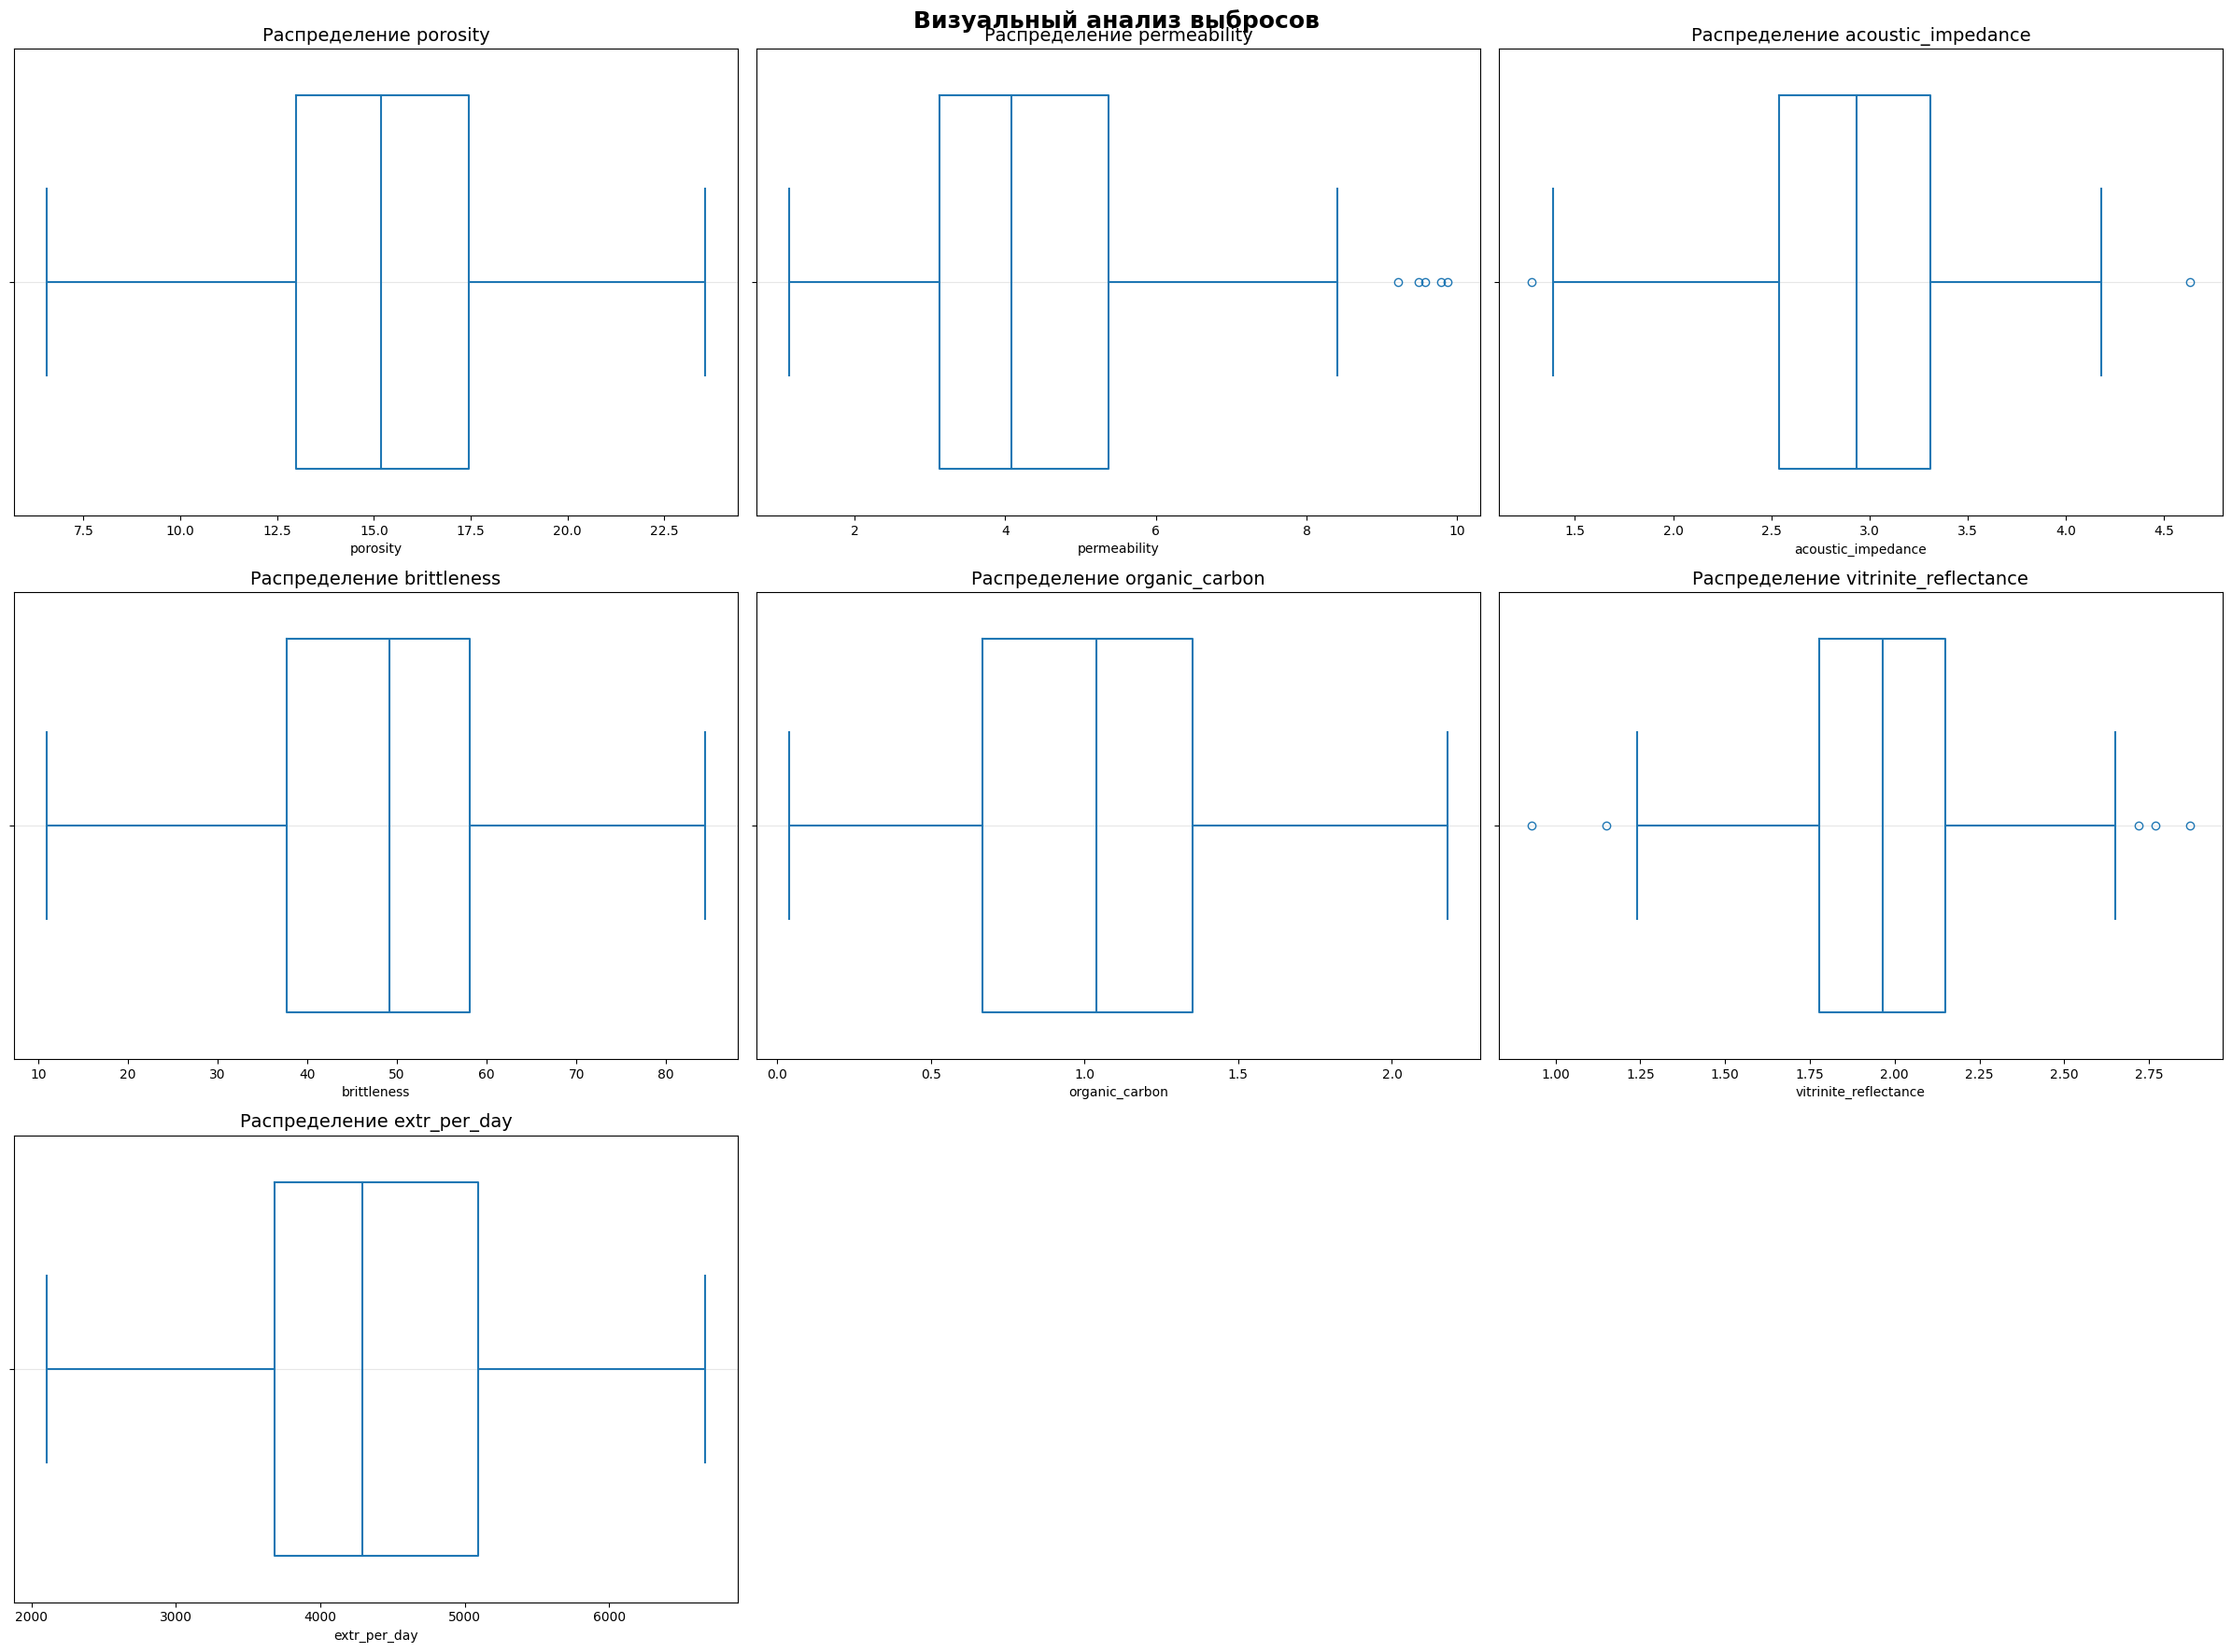

In [14]:
boxplot(well_df, well_df.columns)

In [15]:
def show_outliers(df: pd.DataFrame, columns: list) -> None:
    """
    Выявляет и анализирует выбросы в датафрейме по методу межквартильного размаха.

    Параметры:
        df (pd.DataFrame): Датафрейм для анализа
        columns (list): Список столбцов для анализа
    """
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Определяем выбросы
        lower_outliers = df[df[col] < lower_bound]
        upper_outliers = df[df[col] > upper_bound]

        lower_count = len(lower_outliers)
        upper_count = len(upper_outliers)
        total_count = lower_count + upper_count
        percentage = (total_count / len(df)) * 100

        print(f"Анализ выбросов в столбце '{col}'")
        print()
        print(f"Границы выбросов: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"Количество выбросов: {total_count}")
        print(f"  - Нижних выбросов (< {lower_bound:.2f}): {lower_count}")
        print(f"  - Верхних выбросов (> {upper_bound:.2f}): {upper_count}")
        print(f"Процент выбросов: {percentage:.2f}%")
        print('_' * 35)
        print()

In [16]:
show_outliers(well_df, well_df.columns)

Анализ выбросов в столбце 'porosity'

Границы выбросов: [6.30, 24.16]
Количество выбросов: 0
  - Нижних выбросов (< 6.30): 0
  - Верхних выбросов (> 24.16): 0
Процент выбросов: 0.00%
___________________________________

Анализ выбросов в столбце 'permeability'

Границы выбросов: [-0.23, 8.73]
Количество выбросов: 5
  - Нижних выбросов (< -0.23): 0
  - Верхних выбросов (> 8.73): 5
Процент выбросов: 2.55%
___________________________________

Анализ выбросов в столбце 'acoustic_impedance'

Границы выбросов: [1.38, 4.46]
Количество выбросов: 2
  - Нижних выбросов (< 1.38): 1
  - Верхних выбросов (> 4.46): 1
Процент выбросов: 1.02%
___________________________________

Анализ выбросов в столбце 'brittleness'

Границы выбросов: [6.99, 88.77]
Количество выбросов: 0
  - Нижних выбросов (< 6.99): 0
  - Верхних выбросов (> 88.77): 0
Процент выбросов: 0.00%
___________________________________

Анализ выбросов в столбце 'organic_carbon'

Границы выбросов: [-0.36, 2.38]
Количество выбросов: 0
  - Ни

Визуальный анализ показал наличие выбросов в признаках `permeability`, `acoustic_impedance`, `vitrinite_reflectance`, что подтверждается проверкой по методу `IQR`. Так как ни в одном из признаков колличество выбросов не превышает 2%. Кроме того все признаки находятся в диапазоне допустимых значений и их удаление из данных может потенциально лишить нас ценным наблюдений.

Оставим выбросы в данных, однако при масштабировании признаков примением масштабирование `RobustScaling`, которое учитывает наличие выбросов в данных.

По таргету выбросов не обнаружено.

Вывод:

**Общая характеристика:** Датасет содержит 200 строк и 8 столбцов без пропусков. Полные и неявные дубликаты отсутствуют.

**Неинформативные признаки:** Удален столбец well_id, так как он является просто индексом и не несет полезной для модели информации.

**Аномалии и выбросы:**

Обнаружены 4 строки (2% данных) с физически невозможными отрицательными значениями `organic_carbon`. Эти строки были удалены, так как являются ошибкой измерения.

В признаках `permeability`, `acoustic_impedance` и `vitrinite_reflectance` выявлены статистические выбросы (по методу IQR). Поскольку их количество невелико (<3%) и они находятся в диапазоне физически возможных значений, удаление этих наблюдений сочли нецелесообразным, чтобы не потерять ценную информацию о редких, но потенциально важных свойствах пласта. В таргете выбросов не обнаружено.


*Важное замечание:* Разброс значений `vitrinite_reflectance` (от 0.93 до 2.87) указывает на пристутствие в выборке пород различной зрелости, что стоит учитывать при интепретации результатов модели.

**Итог:** Данные очищены от ошибочных значений. Принято решение сохранить статистические выбросы для дальнейшего анализа. Для последующего масштабирования признаков, содержащих выбросы, будет использован `RobustScaler` как наиболее устойчивый к выбросам метод.

In [17]:
def histplot(df: pd.DataFrame, cols: list) -> None:
    """
    Строит гистограмму распределения признаков с статистическими метриками.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки
        cols (list): Список столбцов для обработки
    """
    n = len(cols)

    # Адаптивная сетка
    n_cols = min(3, n)  # максимум 3 столбца
    n_rows = (n + n_cols - 1) // n_cols  # округляем вверх

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8 * n_cols, 6 * n_rows)
    )

    # Преобразуем axes в плоский список
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Строим гистограмму для каждого признака
    for i, col in enumerate(cols):
        # Расчет статистик
        mean_val = df[col].mean()
        median_val = df[col].median()

        # Тест Шапиро-Уилка на нормальность распределения
        shapiro_stat, shapiro_p = shapiro(df[col])
            # Форматируем p-value
        if shapiro_p < 0.001:
            p_text = f'p-value < 0.001'
        else:
            p_text = f'p-value = {shapiro_p:.3f}'

        # Построение гистограммы
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            ax=axes[i]
        )

        # Добавление вертикальных линий
        axes[i].axvline(mean_val, color='red', linestyle='--',
                       linewidth=2, label='Среднее')
        axes[i].axvline(median_val, color='green', linestyle='-.',
                       linewidth=2, label='Медиана')

        # Добавление текстового поля со всеми статистиками
        stats_text = (f'Среднее: {mean_val:.2f}\n'
                     f'Медиана: {median_val:.2f}\n'
                     f'{p_text}')

        axes[i].text(0.02, 0.98, stats_text,
                    transform=axes[i].transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # Настройка внешнего вида
        axes[i].set_title(f'Распределение {col}', fontsize=14)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')
        axes[i].grid(axis='y', alpha=0.3)
        axes[i].legend(loc='upper right', fontsize=8)

    # Отключаем пустые оси
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        'Гистограмма распределения',
        fontsize=18,
        fontweight='bold',
        y=0.98
    )
    plt.tight_layout()
    plt.show()

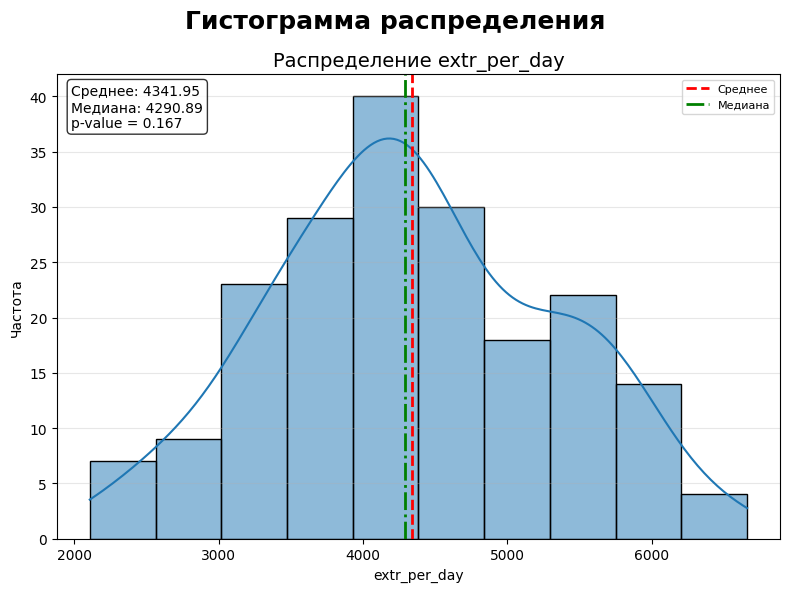

In [18]:
# Строим гистограмму распределения таргета
histplot(well_df,['extr_per_day'])

На гистограмме распределения значений `extr_per_day` видно, что среднее и медианное значения очень близки. Тест Шапиро-Уилка на нормальность распределения показал, что `p_value` значительно больше чем 0.05 ($\alpha$). Таким образом, мы не можем отвергать гипотезу о нормальности распределения таргета.

Изучим распределения признаков.

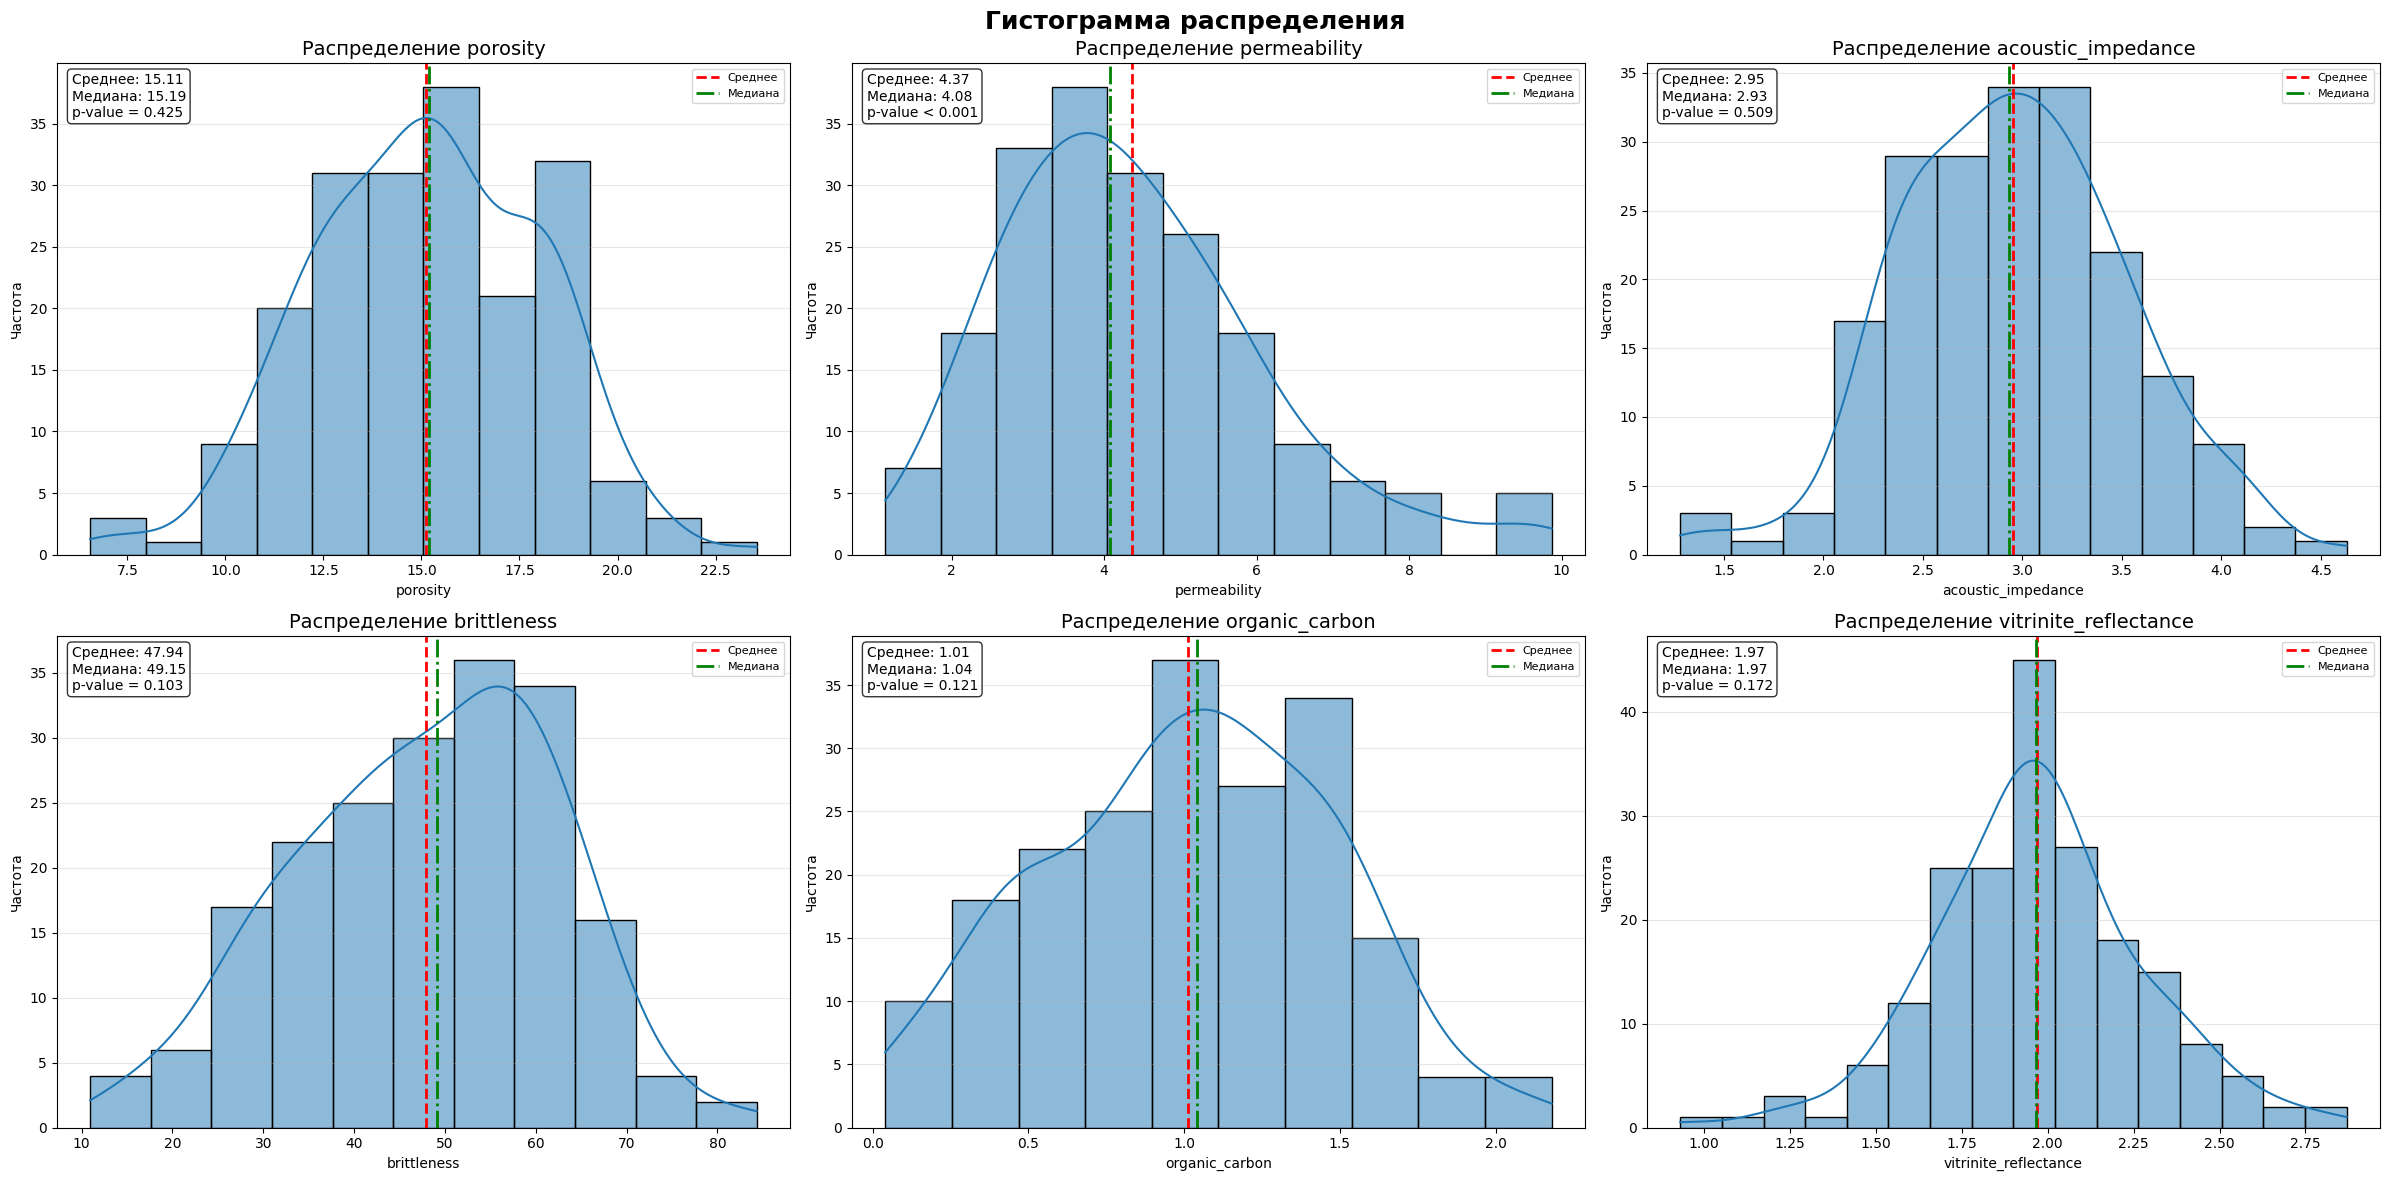

In [19]:
# Строим гистограмму распределения признаков
histplot(well_df,
         well_df.columns.drop('extr_per_day'))

Гистограммы распределения в сочетание с тестом Шапиро-Уилка указывают на отсутствие нормального распределения у признака `permeability`. Для остальных случаях нет основания отвергать предположение о нормальности распределения признаков (так как `p_value` > 0.05 ($\alpha$)).

Нормальное распределение признаков `porosity`, `brittlness`, `organic_carbon` в сочетании с отсутствием выбросов делает допустимым применение `StandardScaler` для масштабирования данных признаков.

Построим `pairplot` для того, чтобы оценить взаимосвязь признаков и таргета.

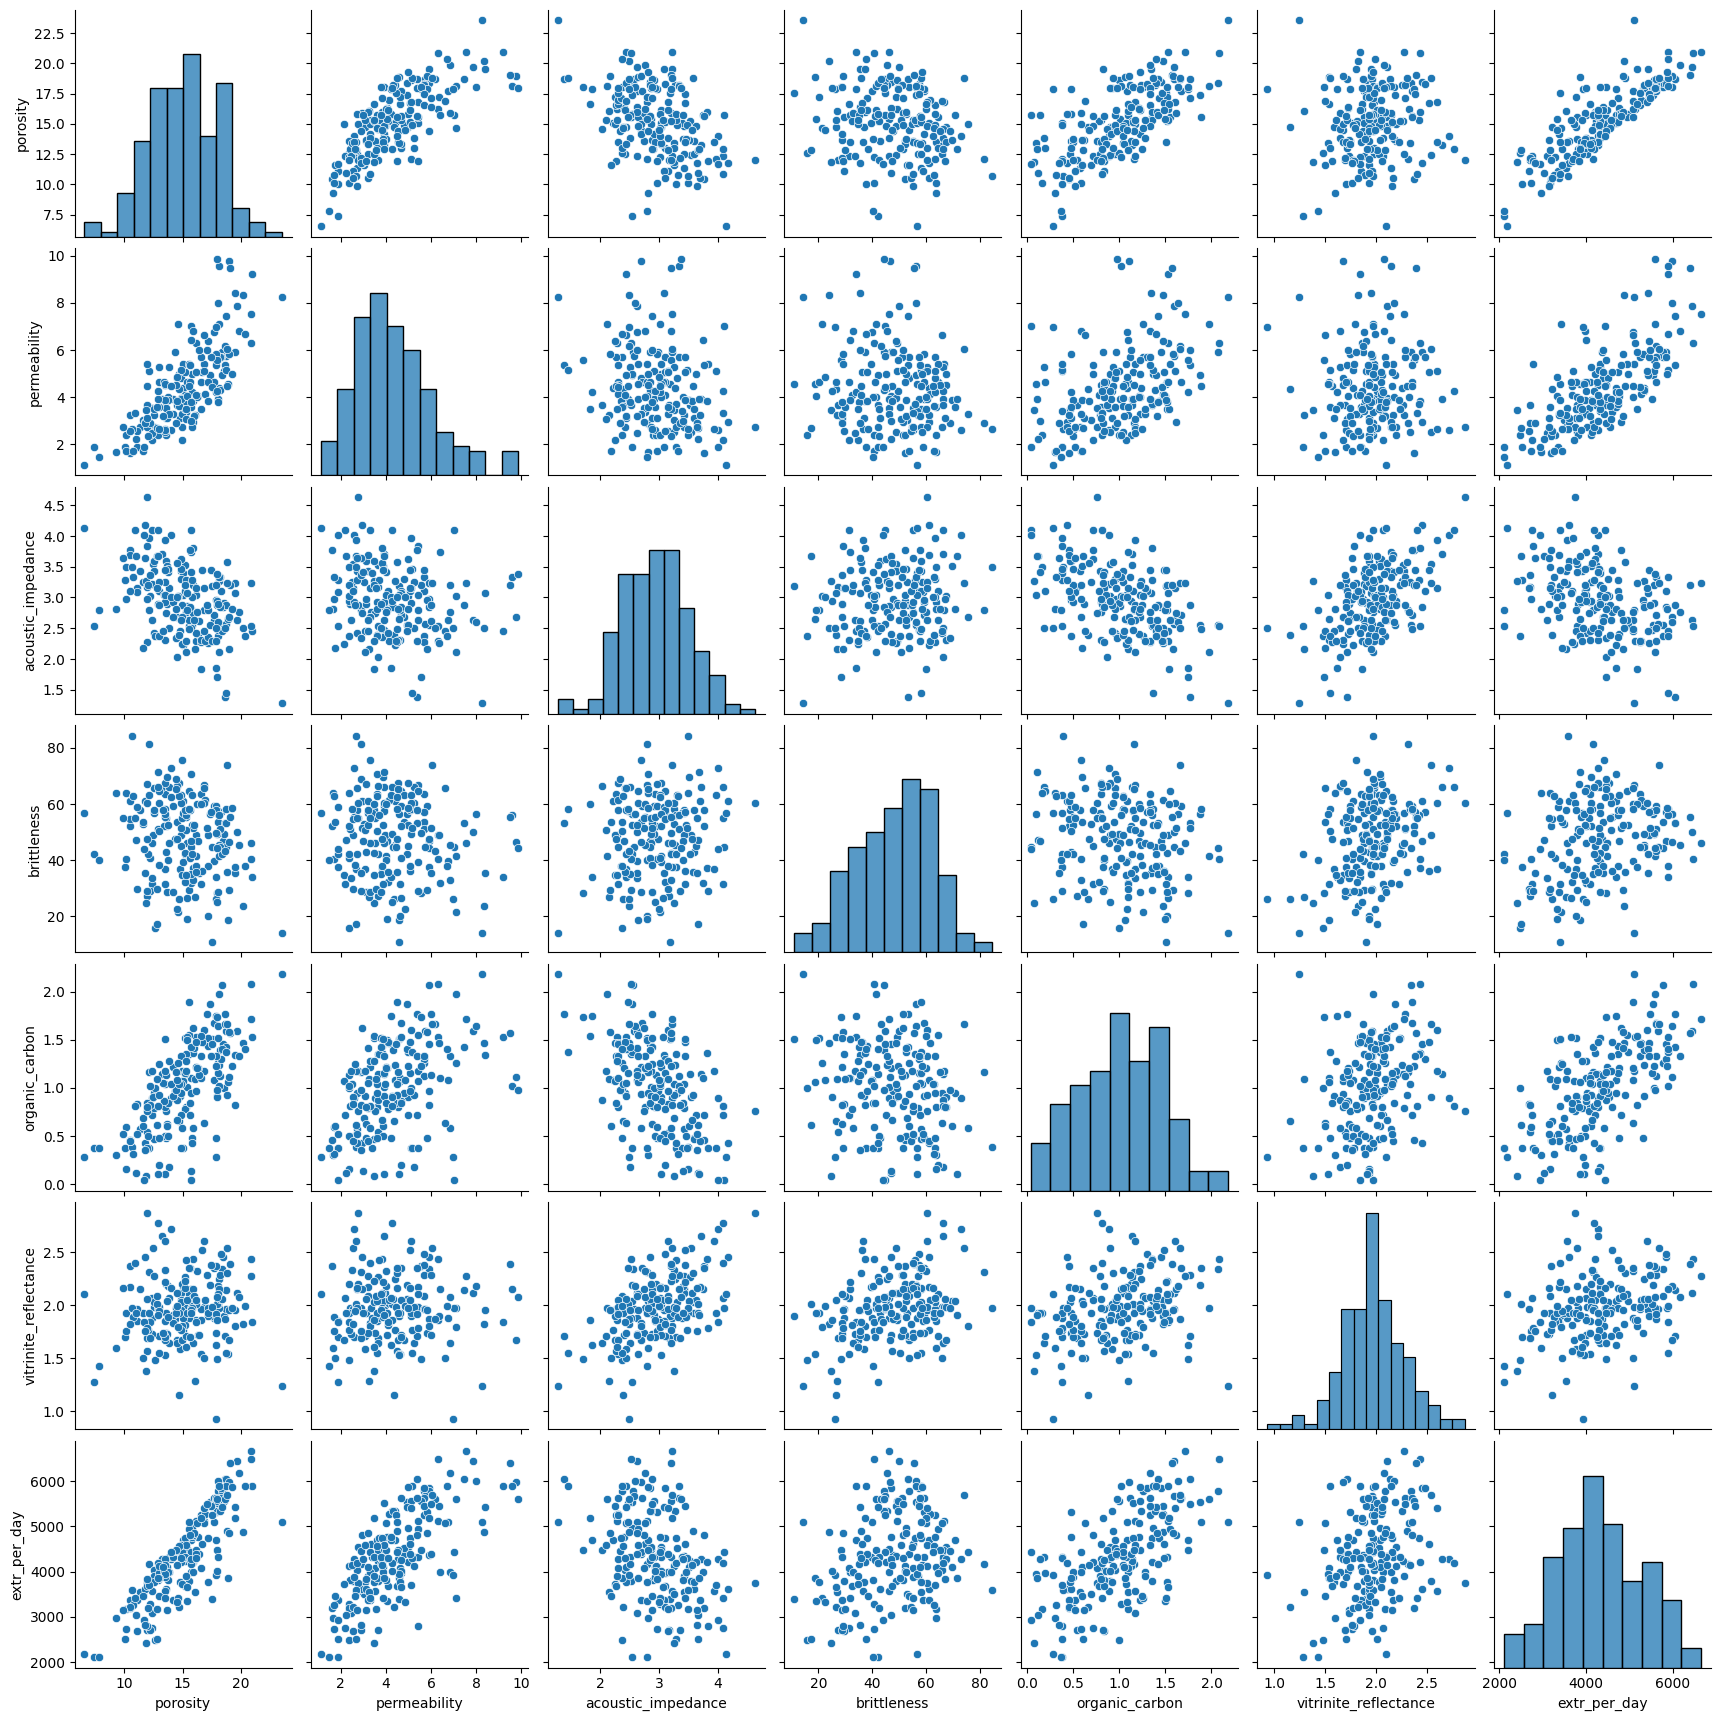

In [20]:
# Строим pairplot
sns.pairplot(well_df)

Таргет показывает выраженную положительную линейную зависимость с признаками `porosity`, `permeability` и `organic_carbon`.

Для признака `porosity` прослеживается выраженная положительная линейная взаимосвязь с признаками `permeability` и `organic_carbon`, что является признаком возможной мультиколинеарности признаков. Визуально также прослеживается слабая отрицательная линейная зависимость с признаком `acoustic_impedance`.

`parmeability` также демонстрирует слабо-выраженную положительную линейную взаимосвязь с `organic_carbon`.

`vertrinite_reflectance` демонстирует наличие положительной линейной взаимосвязт с `acoustic_impendance`.

`brittlness` не демонстрирует выраженной линейной взаимосвязи с рассматриваемыми признаками.

Для оценки наличия линейных взаимосвязей между признаками и таргетом построим матрицу корреляции Пирсона.

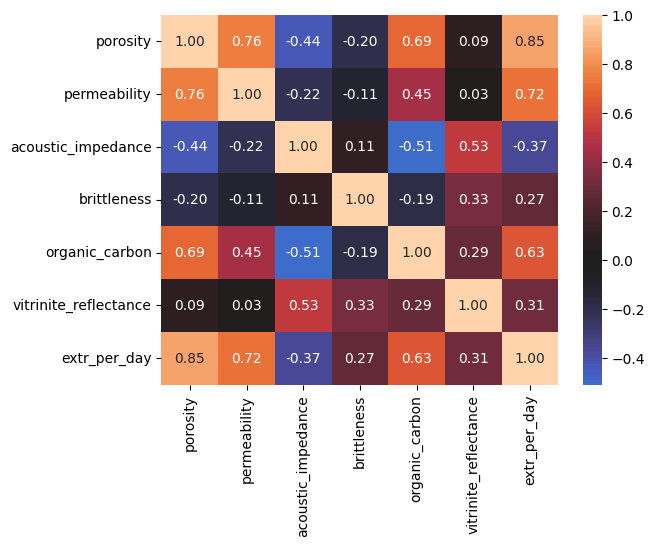

In [21]:
# Строим матрицу корреляции Пирсона
sns.heatmap(well_df.corr(),
            annot=True,
            fmt=".2f",
            center=0)

plt.figsize=(14, 12)

Коэффициент корреляции Пиросна подтверждает наличие значимой положительной линейной взаимосвязи между таргетом и `permeability` (0.72) и `porosity` (0.85). Существует также положительная линейная связь с `organic_carbon` (0.63), однако она выражена не так сильно.

Так как признаки `porosity` и `organic_carbon` также имеют значимую положительную линейную взаимосвязь (0.69), возникает проблема мультиколинеарности для данных признаков.

Аналогичное можно сказать про `porosity` и `permeability` (0.76).

Таким образом, для решения проблемы мультиколинеарности потребуется удалить признаки `permeability` и `organic_carbon`, либо применить регуляризацию во избежание переобучения модели.

**Вывод:** В результате EDA данных можно сделать следующие ключевые выводы:

- Целевая переменная `extr_per_day` имеет распределение, близкое к нормальному. Это благоприятно для построения линейной регрессии, так как нормальность таргета повышает надежность статистических выводов. Применять масштабирование к таргету не нужно;

- Для признаков `porosity`, `brittleness`, `organic_carbon` (p-value > 0.05 по тесту Шапиро-Уилка) допустимо применение `StandardScaler` для масштабирования;

- Для остальных признаков предпочтительнее использовать `RobustScaler` из-за наличия выбросов и отсутствия нормального распределения

- Наиболее сильные линейные связи с таргетом демонстрируют:

  - `porosity` (r = 0.85) — самая сильная положительная связь

  - `permeability` (r = 0.72) — сильная положительная связь

  - `organic_carbon` (r = 0.63) — умеренная положительная связь

  Остальные признаки (`acoustic_impedance`, `brittleness`, `vitrinite_reflectance`) показывают слабую линейную зависимость с таргетом.

- Выявлена проблема мультиколлинеарности между признаками:

  - `porosity` и `permeability` (r = 0.76);

  - `porosity` и `organic_carbon` (r = 0.69);

  - `permeability` и `organic_carbon` (r = 0.48).

  Это может привести к неустойчивости оценок коэффициентов в классической линейной регрессии и требует решения.

Данные подготовлены к моделированию. Выявленные особенности (мультиколлинеарность, различия в распределениях) будут учтены при построении моделей: для классической линейной регрессии будет использован сокращенный набор признаков, а для моделей с регуляризацией — полный набор с соответствующим масштабированием.



In [22]:
# Создадим копию датафрейма со всеми признаками
well_df_full = well_df.copy()

Для построения классической модели линейно регрессии удалим сильно скоррелированные признаки `permeability` и `organic_carbon`, оставив только `porosity`, который показал самую сильную линейную взаимосвязь с таргетом.

In [23]:
# Удаляем мультиколлинеарные признаки
well_df = well_df.drop(columns=['permeability', 'organic_carbon'])

Разделим датасет на матрицу признаков X и вектор таргета y и применим разделение на train и test в соотношении 80/20.

In [24]:
# Разделяем на X и y
X = well_df.copy().drop(columns='extr_per_day')
y = well_df['extr_per_day'].copy()

# Разделяем на train/test
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

Применим машстабирование к признакам:

- `StandardScaler` для `porosity` и `brittleness`;
- `RobustScaler` для `acoustic_impedance` и `vitrinite_reflectance`.

Масштабирование таргета не потребуется.

Также создадим единичный столбец для применения аналитического решения.

In [25]:
# StandardScaler
st_scaler = preprocessing.StandardScaler()

cols_to_st = ['porosity', 'brittleness']

X_train_st_scaled = st_scaler.fit_transform(X_train[cols_to_st])
X_test_st_scaled = st_scaler.transform(X_test[cols_to_st])

# RobustScaler
rb_scaler = preprocessing.RobustScaler()

cols_to_rb = ['acoustic_impedance', 'vitrinite_reflectance']

X_train_rb_scaled = rb_scaler.fit_transform(X_train[cols_to_rb])
X_test_rb_scaled = rb_scaler.transform(X_test[cols_to_rb])

In [26]:
# Создаем единичный столбец
X_train_ones_vector = np.ones((X_train.shape[0], 1))
X_test_ones_vector = np.ones((X_test.shape[0], 1))

In [27]:
# Объединяем
X_train_matrix = np.column_stack([
    X_train_ones_vector,
    X_train_st_scaled,
    X_train_rb_scaled
])

X_test_matrix = np.column_stack([
    X_test_ones_vector,
    X_test_st_scaled,
    X_test_rb_scaled
])

**Вывод:**
- Удалены мультиколлинеарные признаки `permeability` и `organic_carbon`
- Данные разделены на train (80%) и test (20%) с random_state=42
- Для нормально распределенных признаков применен StandardScaler
- Для признаков с выбросами применен RobustScaler
- Добавлен единичный столбец для реализации МНК.

## Решение при помощи МНК

Решим задачу линейной регрессии для нашего набора данных аналитическим способом.

Уравнение линейной регрессии будет иметь вид:

$$y_i = a_0 \cdot 1 + a_1 x_{i1} + a_2 x_{i2} + a_3 x_{i3} + a_4 x_{i4} + \varepsilon_i$$

Где для каждого $y_i$ (значения таргета):

- $a_0$ - свободный член (bias) — коэффициент при единичном столбце;
- $1$ - единичный столбец, добавляемый в матрицу признаков (чтобы модель не проходила через ноль);
- $a_1, a_2, a_3, a_4$ - веса (коэффициенты) при соответствующих признаках;
- $x_{i1}, x_{i2}, x_{i3}, x_{i4}$ - значения признаков `porosity`, `acoustic_impedance`, `brittleness`, `vitrinite_reflectance` для $i$-го наблюдения;
- $\varepsilon_i$ - ошибка (остаток).

Тогда остатки модели:

$$\varepsilon_i = y_i - \hat{a}_0 \cdot 1 - \hat{a}_1 x_{i1} - \hat{a}_2 x_{i2} - \hat{a}_3 x_{i3} - \hat{a}_4 x_{i4}$$

Вычисляем оценки $\hat{a}_k$ при помощи МНК :

1) Функция потерь (сумма квадратов остатков):

$$Q(a_0, a_1, a_2, a_3, a_4) = \sum_{i=1}^{n} (y_i - a_0 - a_1 x_{i1} - a_2 x_{i2} - a_3 x_{i3} - a_4 x_{i4})^2$$

2) Частные производные:

   $\frac{\partial Q}{\partial a_0} = -2 \sum_{i=1}^{n} (y_i - a_0 - a_1 x_{i1} - a_2 x_{i2} - a_3 x_{i3} - a_4 x_{i4})$;

   $\frac{\partial Q}{\partial a_1} = -2 \sum_{i=1}^{n} x_{i1} (y_i - a_0 - a_1 x_{i1} - a_2 x_{i2} - a_3 x_{i3} - a_4 x_{i4})$;

   $\frac{\partial Q}{\partial a_2} = -2 \sum_{i=1}^{n} x_{i2} (y_i - a_0 - a_1 x_{i1} - a_2 x_{i2} - a_3 x_{i3} - a_4 x_{i4})$;

   $\frac{\partial Q}{\partial a_3} = -2 \sum_{i=1}^{n} x_{i3} (y_i - a_0 - a_1 x_{i1} - a_2 x_{i2} - a_3 x_{i3} - a_4 x_{i4})$;

   $\frac{\partial Q}{\partial a_4} = -2 \sum_{i=1}^{n} x_{i4} (y_i - a_0 - a_1 x_{i1} - a_2 x_{i2} - a_3 x_{i3} - a_4 x_{i4})$.

3) Приравнивая производные к нулю, получаем систему нормальных уравнений:

\begin{cases}
\sum_{i=1}^{n} y_i = n a_0 + a_1\sum_{i=1}^{n} x_{i1} + a_2\sum_{i=1}^{n} x_{i2} + a_3\sum_{i=1}^{n} x_{i3} + a_4\sum_{i=1}^{n} x_{i4} \\[2ex]
\sum_{i=1}^{n} x_{i1}y_i = a_0\sum_{i=1}^{n} x_{i1} + a_1\sum_{i=1}^{n} x_{i1}^2 + a_2\sum_{i=1}^{n} x_{i1}x_{i2} + a_3\sum_{i=1}^{n} x_{i1}x_{i3} + a_4\sum_{i=1}^{n} x_{i1}x_{i4} \\[2ex]
\sum_{i=1}^{n} x_{i2}y_i = a_0\sum_{i=1}^{n} x_{i2} + a_1\sum_{i=1}^{n} x_{i1}x_{i2} + a_2\sum_{i=1}^{n} x_{i2}^2 + a_3\sum_{i=1}^{n} x_{i2}x_{i3} + a_4\sum_{i=1}^{n} x_{i2}x_{i4} \\[2ex]
\sum_{i=1}^{n} x_{i3}y_i = a_0\sum_{i=1}^{n} x_{i3} + a_1\sum_{i=1}^{n} x_{i1}x_{i3} + a_2\sum_{i=1}^{n} x_{i2}x_{i3} + a_3\sum_{i=1}^{n} x_{i3}^2 + a_4\sum_{i=1}^{n} x_{i3}x_{i4} \\[2ex]
\sum_{i=1}^{n} x_{i4}y_i = a_0\sum_{i=1}^{n} x_{i4} + a_1\sum_{i=1}^{n} x_{i1}x_{i4} + a_2\sum_{i=1}^{n} x_{i2}x_{i4} + a_3\sum_{i=1}^{n} x_{i3}x_{i4} + a_4\sum_{i=1}^{n} x_{i4}^2
\end{cases}

что в матричной форме эквивалентно:

$$\mathbf{X}^T\mathbf{X}\mathbf{a} = \mathbf{X}^T\mathbf{y}$$

где:

- $\mathbf{X}$ - матрица признаков размера $n \times 5$ с единичным столбцом (матрица планирования);
- $\mathbf{X}^T$ - транспонированная матрица $\mathbf{X}$;
- $\mathbf{a}$ - искомый вектор коэффициентов (весов);
- $\mathbf{y}$ - вектор фактических значений целевой переменной.

Тогда решение методом наименьших квадратов:

$$\hat{\mathbf{a}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

Создадим функцию для аналитического решения.

In [28]:
def solve_linear_regression(X, y):
    """
    Решает задачу линейной регрессии

    Параметры:
        X (np.array): Матрица признаков
        y (np.array): Вектор фактических значений

    Возвращает:
        a (np.array): Вектор весов
    """
    # Находим матрицу X^T
    X_T = X.transpose()

    # Находим X_TX
    XT_X = X_T.dot(X)

    # Составляем вектор y
    y = y.to_numpy()

    # Находим X_TY
    XT_Y = X_T.dot(y)

    # Находим обратную матрицу XT_X(-1)
    XT_X_inverted = np.linalg.inv(XT_X)

    # Находим a
    a = XT_X_inverted.dot(XT_Y)

    # Выводим искомые веса
    print("Искомые веса:")
    for i in range(len(a)):
        print(f"a_{i}: {a[i]}")

    return a

In [29]:
# Применим на train
a_vector = solve_linear_regression(X_train_matrix, y_train)

Искомые веса:
a_0: 4330.836982609618
a_1: 831.9084719562024
a_2: 388.25531031852694
a_3: -148.77775328831052
a_4: 144.9496807068402


Вектор весов $\hat{\mathbf{a}}$ найден.
Попробуем решить эту же задачу при помощи встроенного класса `LinearRegression` из sklearn и сравним полученные веса.

In [30]:
# Создаем объект линейной регрессии
lr = linear_model.LinearRegression(fit_intercept=False)

# Обучаем
lr.fit(X_train_matrix, y_train)

# Список названий признаков
feature_names = X_train.columns.tolist()

# Добавляем единичный столбец в список названий
feature_names_with_bias = ['bias'] + feature_names

lr_df = pd.DataFrame({
    'Признаки': feature_names_with_bias,
    'Веса_sklearn': lr.coef_,
    'Веса_аналитическое_решение': a_vector
})

lr_df

,Признаки,Веса_sklearn,Веса_аналитическое_решение
0,bias,4330.836983,4330.836983
1,porosity,831.908472,831.908472
2,acoustic_impedance,388.255310,388.255310
3,brittleness,-148.777753,-148.777753
4,vitrinite_reflectance,144.949681,144.949681


Веса, полученные при помощи аналитического решения и при помощи встроенного класса sklearn идентичны. Это значит, что для решения задачи линеной регрессии допустимо пользоваться встроенными интсрументами sklearn.

Наибольший вес был присвоен признаку `porosity`, что объясняется самой высокой корреляцией с таргетом. Остальным признакам были присвоены существенно меньшие веса так как их взаимосвязь с таргетом слабее. Признаку `brittleness` был присвоен отрицательный вес, при этом коэффициент корреляции таргета с данным признаком был положительным, но низким (0.27). Это может быть обусловлено проявлением условных зависимостей между признаками, в то время как коэффициент корреляции признака учитывает только безусловное влияние признака на таргет.

Выполним предсказания на train и test и оценим $MSE$, $MAE$, $MAPE$ и $R^2$

In [31]:
# Предсказываем на train
y_pred_train = lr.predict(X_train_matrix)
y_pred_test = lr.predict(X_test_matrix)

In [32]:
def evaluate_regression(y_true, y_pred):
    """
    Оценивает качество регрессионной модели.

    Параметры:
        y_true (np.array): Фактические значения
        y_pred (np.array): Предсказанные значения

    Возвращает:
        pd.DataFrame: Датафрейм с метриками
    """
    # Расчет метрик
    mse = metrics.mean_squared_error(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mape = metrics.mean_absolute_percentage_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)

    # Создание датафрейма с результатами
    evaluation_df = pd.DataFrame({
        'MSE': [f"{mse:.2f}"],
        'MAE': [f"{mae:.2f}"],
        'MAPE': [f"{mape:.2f}"],
        'R^2': [f"{r2:.4f}"]
    })

    return evaluation_df

In [33]:
# Оцениваем предсказания
evaluation_train_df = evaluate_regression(y_train, y_pred_train)
evaluation_test_df = evaluate_regression(y_test, y_pred_test)

print("MSE, MAE, MAPE, R^2")
print("Для train:")
display(evaluation_train_df)

print()
print("Для test:")
display(evaluation_test_df)

MSE, MAE, MAPE, R^2
Для train:


,MSE,MAE,MAPE,R^2
0,57088.84,181.49,0.04,0.9395



Для test:


,MSE,MAE,MAPE,R^2
0,41555.80,131.53,0.03,0.9565


**Вывод:**

В ходе выполнения задания было получено аналитическое решение при помощи МНК, а также реализована соответствующая функция на Python и проведено сравнение с моделью `LinearRegression` из sklearn. Полное совпадение весов подтверждает корректность обеих реализаций.

Анализ коэффициентов показал, что наиболее важным признаком является
`porosity`, что согласуется с результатами корреляционного анализа. Отрицательный вес признака `brittleness` при положительной парной корреляции, вероятно обусловлен сочетанием взаимосвязей между признаками в многомерной модели.

Модель показала более точные результаты на тестовых данных (в среднем ошибается на 1% реже чем на тренировочных) (MAPE = 0.03 на `test`против 0.04. на `train`). Высокий $R^2$ тажке указывает на точность предсказания (95% на `test` против 93% на `train`). Модель успешно обобщает выявленные закономерности и показывает высокую устойчивость. Небольшое преимущество тестовой выборки, вероятно, связано со случайными особенностями разбиения данных.

## Решением при помощи градиентного спуска

Реализуем алгоритм классического градиентного спуска.

Вектор градиента из рассчитанных ранее частных производных $\frac{\partial Q}{\partial a_0}, \frac{\partial Q}{\partial a_1}, \frac{\partial Q}{\partial a_2}, \frac{\partial Q}{\partial a_3}, \frac{\partial Q}{\partial a_4}$ и имеет вид:
$$\nabla Q(a) = \frac{2}{n} X^T (X \cdot a - y)$$.

где:

- $n$ - количество наблюдений в выборке;
- $X$ - матрица признаков с единичным столбцом;
- $X^T$ - транспонированная матрица признаков с единичным столбцом;
- $a$ - текущий вектор весов;
- $y$ - вектор фактических значений.

Алгоритм градиентного спуска подразумевает движение в противоположном направлении вектора градиента. При этом на каждой итерации происходит обновлении вектора весов:

$$a_{k+1} = a_{k} - lr * \nabla Q(a)$$

где:

- $lr$ - гиперпараметр (скорость обучения, шаг);
- $\nabla Q(a)$ - текущее значение вектора градиента.

Скорость обучения и количество итераций градиентного спуска - это гиперпараметры, которые мы можем подбирать для нахождения оптимальной сходимости.

Если установить слишком большой lr, алгоритм может разойтись и мы никогда не достигнем сходимости. В случае, если значение скорости обучения окажется слишком медленным, наш алгоритм будет двигаться слишком медленно к точке локального минимума, не достигнув сходимости за нужное количество итераций. Поэтому крайне важно подобрать оптимальное значение количества итераций и скорости обучения.

Мы уже вычислили оптимальные веса для нашей функции при помощи МНК.
Попробуем рассчитать оптимальные веса при помощи алгоритма градиентного спуска:

1) Зададим начальное приближение вектора весов $a$;
2) Рассчитаем предсказания как $X$*a;
3) Рассчитаем остатки как разницу между реальным и предсказанным значением;
4) Найдем градиент;
5) Обновим вектор весов;
6) Рассчитаем MSE;
7) Повторим действия в соответствии с количеством интераций.

Кроме того реализиуем функцию, которая найдет оптимальные гиперпараметры градиентного спуска для достижения весов, приближенных к тем, которые мы рассчитали при помощи МНК.

В качестве возможных значений lr возьмем [0.01, 0.05, 0.1], а в качестве максимального количества итераций [100, 500, 1000].

In [34]:
def predict(X, weights):
    """
    Расчёт предсказания модели
    """
    return np.dot(X, weights)

In [35]:
def mse_loss(y_true, y_pred):
    """
    Расчёт значения функции ошибки MSE
    """
    return np.mean((y_true - y_pred) ** 2)

In [36]:
def gradient_descent(
    X_train, y_train, X_test, y_test,
    lr=0.1, n_iter=1000, calc_metrics=True, print_metrics=True
):
    """
    Реализует алгоритм градиентного спуска для задачи
    линейной регрессии.

    Параметры:
    X_train (np.array):
        Матрица признаков train
    y_train (np.array):
        Целевая переменная train
    X_test (np.array):
        Матрица признаков test
    y_test (np.array):
        Целевая переменная test
    lr (float):
        Скорость обучения.
        По умолчанию: 0.1
    n_iter (int):
        Количество итераций
        По умолчанию: 1000
    calc_metrics (bool):
        Расчет MSE, R^2
        По умолчанию: True
    print_metrics (bool):
        Вывод промежуточных результатов
        По умолчанию: True

    Возвращает:
    weights (np.array):
        Оптимальный вектор весов
    train_losses, test_losses (list):
        Список со значениями MSE для train и test
    train_scores (list), test_scores (list):
        Список со значениями R^2 score для train и test
    """
    np.random.seed(42)

    n_samples, n_features = X_train.shape

    # Задаем начальное приближение вектора весов
    weights = np.random.randn(n_features) * 0.01
    train_losses = []
    test_losses = []
    train_scores = []
    test_scores = []

    for i in range(n_iter):
        # Предсказание на обучающей выборке для расчета градиента
        y_train_pred = predict(X_train, weights)

        # Рассчитываем остатки
        error = y_train_pred - y_train

        # Находим градиент
        grad = (2 / n_samples) * np.dot(X_train.T, error)

        # Обновляем веса
        weights = weights - lr * grad

        # Рассчитываем метрики на train и test выборках
        if calc_metrics:
            # Метрики на train
            train_loss = mse_loss(y_train, y_train_pred)
            train_r2 = metrics.r2_score(y_train, y_train_pred)

            # Метрики на test
            y_test_pred = predict(X_test, weights)
            test_loss = mse_loss(y_test, y_test_pred)
            test_r2 = metrics.r2_score(y_test, y_test_pred)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_scores.append(train_r2)
            test_scores.append(test_r2)

            # Выводим промежуточные результаты
            if print_metrics and i % 10 == 0:
                print(f"Итерация {i+1}: Train MSE = {train_loss:.4f}, Test MSE = {test_loss:.4f}")
                print(f"R^2 train = {train_r2:.4f}, R^2 test = {test_r2:.4f}")

    return weights, train_losses, test_losses, train_scores, test_scores

In [37]:
def find_best_params(
    X_train, y_train, X_test, y_test,
    rates: list, iterations: list, mse_vector: np.array,
    tolerance: float = 1e-6
):
    """
    Подбирает оптимальные гиперпараметры градиентного спуска,
    минимизирующие разницу с МНК-решением.

    Параметры:
    X_train (np.array):
        Матрица признаков train
    y_train (np.array):
        Целевая переменная train
    X_test (np.array):
        Матрица признаков test
    y_test (np.array):
        Целевая переменная test
    rates (list):
        Список скоростей обучения
    iterations (list):
        Список количества итераций
    mse_vector (np.array):
        Вектор весов из МНК
    tolerance (float):
        Допустимое отклонение

    Возвращает:
    tuple: (best_weights, best_params, best_change)
        best_weights: оптимальный вектор весов
        best_params: словарь с лучшими параметрами
        best_change: минимальная достигнутая разница
    """
    best_change = float('inf')
    best_weights = None
    best_params = None

    print(f"{'-'*60}")
    print("Подбор гиперпараметров для максимального приближения")
    print("к весам, полученным при помощи МНК")
    print(f"{'-'*60}")
    print("Вектор весов, полученный аналитически:")
    print(mse_vector)

    for rate in rates:
        for n_iter in iterations:
            # Запускаем градиентный спуск
            weights, train_losses, test_losses, train_scores, test_scores = gradient_descent(
                X_train, y_train, X_test, y_test,
                lr=rate, n_iter=n_iter,
                calc_metrics=False, print_metrics=False
            )

            # Вычисляем разницу с МНК-решением
            current_change = np.linalg.norm(weights - mse_vector)

            print(f"lr={rate}, iter={n_iter}: diff={current_change:.2e}")

            # Обновляем лучший результат
            if current_change < best_change:
                best_change = current_change
                best_weights = weights.copy()
                best_params = {'lr': rate, 'n_iter': n_iter}

                # Проверяем, достигли ли нужной точности
                if best_change <= tolerance:
                    print(f"{'-'*50}")
                    print("Достигнуто максимальное приближение к МНК.")
                    print(f"Параметры: lr = {rate}, n_iter = {n_iter}")
                    print(f"Разница: {best_change:.2e}")
                    print(f"Полученный вектор весов: {best_weights}")
                    print(f"{'-'*60}")
                    return best_weights, best_params, best_change

    # Если точность не достигнута, возвращаем лучшее из найденного
    print(f"{'-'*50}")
    print("Подбор завершен")
    print(f"Лучшие параметры: lr={best_params['lr']}, n_iter={best_params['n_iter']}")
    print(f"Минимальная разница с МНК: {best_change:.2e}")
    print(f"Полученный вектор весов: {best_weights}")
    print(f"{'-'*50}")

    return best_weights, best_params, best_change

In [38]:
weights, params, change = find_best_params(
    X_train_matrix,
    y_train,
    X_test_matrix,
    y_test,
    rates=[0.01, 0.05, 0.1],
    iterations=[100, 500, 1000],
    mse_vector=a_vector
)

------------------------------------------------------------
Подбор гиперпараметров для максимального приближения
к весам, полученным при помощи МНК
------------------------------------------------------------
Вектор весов, полученный аналитически:
[4330.83698261  831.90847196  388.25531032 -148.77775329  144.94968071]
lr=0.01, iter=100: diff=6.09e+02
lr=0.01, iter=500: diff=2.59e+00
lr=0.01, iter=1000: diff=4.75e-01
lr=0.05, iter=100: diff=2.53e+00
lr=0.05, iter=500: diff=2.96e-03
lr=0.05, iter=1000: diff=6.52e-07
--------------------------------------------------
Достигнуто максимальное приближение к МНК.
Параметры: lr = 0.05, n_iter = 1000
Разница: 6.52e-07
Полученный вектор весов: [4330.83698257  831.90847222  388.25531044 -148.77775279  144.94968041]
------------------------------------------------------------


Наибольшее приближение к вектору весов, полученном аналитически достигается при `lr` = 0.05 и `n_iter` = 1000. При данных параметрах вектор весов, полученный при помощи градиентного спуска, практически совпадает с вектором весов, полученным при помощи МНК.

Реализуем алгоритм градиентного спуска, в котором расчет весов происходит не по всей выборке, а по мини-батчам, и сравним скорость работы и эффективность двух алгоритмов. В качестве размера батча возьмем 36. Количество эпох и learning rate возьмем равными оптимальным параметрам, рассчитанным для классического градиентного спуска.

Основные отличия от классической версии алгоритма:

- Внутри одной эпохи веса обновляются несколько раз - после каждого мини-батча, а не один раз после просмотра всей выборки;

- Перед каждой эпохой данные перемешиваются, чтобы батчи содержали разные комбинации объектов;

- За одну эпоху алгоритм проходит через все обучающие примеры ровно один раз, разбив их на батчи размера 36.

In [39]:
def mini_batch_gradient_descent(
    X_train, y_train, X_test, y_test,
    lr=0.1, n_epochs=1000, calc_metrics=True, print_metrics=True,
    batch_size=36
):
    """
    Реализует алгоритм mini-batch
    градиентного спуска для задачи
    линейной регрессии.

    Параметры:
    X_train (np.array):
        Матрица признаков train
    y_train (np.array):
        Целевая переменная train
    X_test (np.array):
        Матрица признаков test
    y_test (np.array):
        Целевая переменная test
    lr (float):
        Скорость обучения.
        По умолчанию: 0.1
    n_epochs (int):
        Количество эпох
        По умолчанию: 1000
    calc_metrics (bool):
        Расчет MSE, R^2.
        По умолчанию: True
    print_metrics (bool):
        Вывод промежуточных результатов
        По умолчанию: True
    batch_size (int):
        Размер батча
        По умолчанию: 36

    Возвращает:
    weights (np.array):
        Оптимальный вектор весов
    train_losses, test_losses (list):
        Список со значениями MSE для train и test
    train_scores, test_scores (list):
        Список со значениями R^2 для train и test
    """
    if hasattr(X_train, 'values'):
        X_train = X_train.values
        X_test = X_test.values
    if hasattr(y_train, 'values'):
        y_train = y_train.values
        y_test = y_test.values

    np.random.seed(42)

    n_samples, n_features = X_train.shape

    # Задаем начальное приближение вектора весов
    weights = np.random.randn(n_features) * 0.01
    train_losses = []
    test_losses = []
    train_scores = []
    test_scores = []

    for epoch in range(n_epochs):
        # Перемешиваем данные
        idx = np.random.permutation(n_samples)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        # Проходим по батчам
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            # Предсказание на батче
            y_pred = predict(X_batch, weights)

            # Рассчитываем остатки
            error = y_pred - y_batch

            # Находим градиент
            grad = (2 / batch_size) * np.dot(X_batch.T, error)

            # Обновляем веса
            weights = weights - lr * grad

        # Считаем метрики по эпохе
        if calc_metrics:
            # Метрики на train
            y_train_pred_full = predict(X_train, weights)
            train_loss = mse_loss(y_train, y_train_pred_full)
            train_r2 = metrics.r2_score(y_train, y_train_pred_full)

            # Метрики на test
            y_test_pred_full = predict(X_test, weights)
            test_loss = mse_loss(y_test, y_test_pred_full)
            test_r2 = metrics.r2_score(y_test, y_test_pred_full)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_scores.append(train_r2)
            test_scores.append(test_r2)

            # Выводим промежуточные результаты
            if print_metrics and epoch % 10 == 0:
                print(f"Эпоха {epoch}: Train MSE = {train_loss:.4f}, Test MSE = {test_loss:.4f}")

    return weights, train_losses, test_losses, train_scores, test_scores

In [40]:
# Обучаем градиентный спуск
cl_weights, cl_tr_losses, cl_tst_losses, cl_train_scores, cl_tst_scores = gradient_descent(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_iter=params['n_iter'], calc_metrics=True,
    print_metrics=False
)

In [41]:
# Обучаем mini-batch градиентный спуск
mb_weights, mb_tr_losses, mb_tst_losses, mb_tr_scores, mb_tst_scores = mini_batch_gradient_descent(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_epochs=params['n_iter'],
    calc_metrics=True, print_metrics=False,
    batch_size=36
)

In [42]:
%%timeit
gradient_descent(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_iter=params['n_iter'], calc_metrics=True,
    print_metrics=False
)

1.95 s ± 182 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
%%timeit
mini_batch_gradient_descent(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_epochs=params['n_iter'],
    calc_metrics=True, print_metrics=False,
    batch_size=36
)

1.09 s ± 11.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Mini-batch градиентный спуск показал более высокую скорость работы, а тажке большую стабильность. В случае с небольшой выборкой это преимущество может быть не таким явным, однако для больших выборок такие свойства могут быть критичными.

Сравним также основные метрики MSE, MAE, MAPE и R^2 для двух алгоритмов.

In [44]:
# Оцениваем эффективность на train
cl_y_train_pred = predict(X_train_matrix, cl_weights)
mb_y_train_pred = predict(X_train_matrix, mb_weights)

cl_train_df = evaluate_regression(y_train, cl_y_train_pred)
mb_train_df = evaluate_regression(y_train, mb_y_train_pred)

print("MSE, MAE, MAPE, R^2 для train")
print("Классический гр. спуск:")
display(cl_train_df)

print()
print("Mini-batch градиентный спуск:")
display(mb_train_df)

print()
print("МНК:")
display(evaluation_train_df)

MSE, MAE, MAPE, R^2 для train
Классический гр. спуск:


,MSE,MAE,MAPE,R^2
0,57088.84,181.49,0.04,0.9395



Mini-batch градиентный спуск:


,MSE,MAE,MAPE,R^2
0,57114.06,181.69,0.04,0.9395



МНК:


,MSE,MAE,MAPE,R^2
0,57088.84,181.49,0.04,0.9395


In [45]:
# Оцениваем эффективность на test
cl_y_test_pred = predict(X_test_matrix, cl_weights)
mb_y_test_pred = predict(X_test_matrix, mb_weights)

cl_test_df = evaluate_regression(y_test, cl_y_test_pred)
mb_test_df = evaluate_regression(y_test, mb_y_test_pred)

print("MSE, MAE, MAPE, R^2 для test")
print("Классический гр. спуск:")
display(cl_test_df)

print()
print("Mini-batch градиентный спуск:")
display(mb_test_df)

print()
print("МНК:")
display(evaluation_test_df)

MSE, MAE, MAPE, R^2 для test
Классический гр. спуск:


,MSE,MAE,MAPE,R^2
0,41555.80,131.53,0.03,0.9565



Mini-batch градиентный спуск:


,MSE,MAE,MAPE,R^2
0,42170.16,131.56,0.03,0.9558



МНК:


,MSE,MAE,MAPE,R^2
0,41555.80,131.53,0.03,0.9565


Все три способа показали похожие результаты как на обучающей, так и на тестовой выборках. На тестовой выборке удалось добиться точности предсказания примерно 95%. При этом mini-batch показал чуть меньшее значение $R^2$.

In [46]:
def plot_method_comparison(train_losses, test_losses, method_name):
    """
    Строит совмещенный график для одного метода
    """
    plt.figure(figsize=(10, 6))

    plt.plot(train_losses, label='Train MSE', linewidth=2, color='blue')
    plt.plot(test_losses, label='Test MSE', linewidth=2, color='red', alpha=0.7)

    plt.xlabel('Итерация / Эпоха')
    plt.ylabel('MSE')
    plt.title(f'{method_name} - Сравнение сходимости на train и test')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

    plt.tight_layout()
    plt.show()

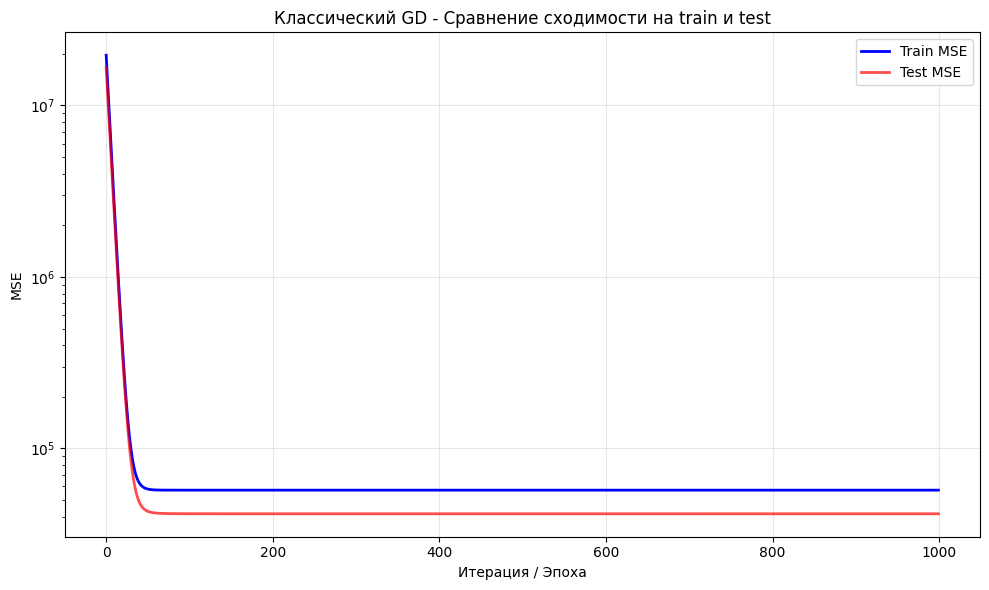

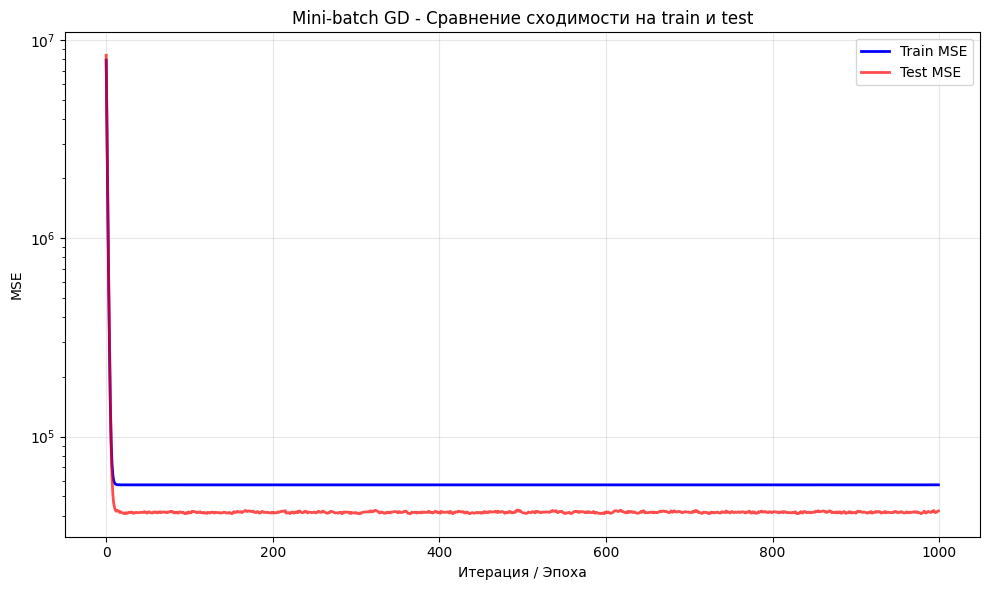

In [47]:
plot_method_comparison(cl_tr_losses, cl_tst_losses, 'Классический GD')
plot_method_comparison(mb_tr_losses, mb_tst_losses, 'Mini-batch GD')

Графики сходимости демонстрируют, что оба метода сошлись к одному решению. При этом отсутствуют признаки переобучения - кривые train и test идут параллельно, разрыв не растет. Если бы модель переобучалась, test MSE росла бы или была намного выше train.

**Вывод:** Эксперимент показал, что оба варианта градиентного спуска позволяют достичь качества, сопоставимого с МНК ($R^2$ около 0,95 на тесте). При этом mini-batch версия оказалась быстрее и стабильнее. Улучшить прогноз относительно МНК не удалось (это ожидаемо для линейной задачи), однако градиентные методы являются незаменимыми при работе с огромными выборками, где аналитическое решение вычислительно невозможно.

## Решение с применением L1 и L2 регуляризации

Проверим, какие показатели мы бы получили, если бы обучили градиентный метод без удаления мультиколлинеарных признаков.

В качестве алгоритма возьмем классический градиентный спуск, так как он продемонстрировал чуть лучшие результаты по части метрик (MSE и MAE чуть ниже, R^2 чуть выше).

In [48]:
# Разделяем на X и y
X = well_df_full.copy().drop(columns='extr_per_day')
y = well_df_full['extr_per_day'].copy()

# Разделяем на train/test
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

Применим машстабирование к признакам:

- `StandardScaler` для `porosity` и `brittleness` и `organic_carbon`;
- `RobustScaler` для `acoustic_impedance`, `vitrinite_reflectance` и `permeability`.

Масштабирование таргета не потребуется.

Также создадим единичный столбец для применения аналитического решения.

In [49]:
# StandardScaler
st_scaler = preprocessing.StandardScaler()

cols_to_st = ['porosity', 'brittleness', 'organic_carbon']

X_train_st_scaled = st_scaler.fit_transform(X_train[cols_to_st])
X_test_st_scaled = st_scaler.transform(X_test[cols_to_st])

# RobustScaler
rb_scaler = preprocessing.RobustScaler()

cols_to_rb = ['acoustic_impedance', 'vitrinite_reflectance', 'permeability']

X_train_rb_scaled = rb_scaler.fit_transform(X_train[cols_to_rb])
X_test_rb_scaled = rb_scaler.transform(X_test[cols_to_rb])

In [50]:
# Создаем единичный столбец
X_train_ones_vector = np.ones((X_train.shape[0], 1))
X_test_ones_vector = np.ones((X_test.shape[0], 1))

In [51]:
# Объединяем
X_train_matrix = np.column_stack([
    X_train_ones_vector,
    X_train_st_scaled,
    X_train_rb_scaled
])

X_test_matrix = np.column_stack([
    X_test_ones_vector,
    X_test_st_scaled,
    X_test_rb_scaled
])

In [52]:
# Обучаем градиентный спуск
weights, tr_losses, tst_losses, train_scores, tst_scores = gradient_descent(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_iter=params['n_iter'], calc_metrics=True,
    print_metrics=False
)

In [53]:
# Оцениваем эффективность на train и test
y_train_pred = predict(X_train_matrix, weights)
y_test_pred = predict(X_test_matrix, weights)

ev_train_df = evaluate_regression(y_train, y_train_pred)
ev_test_df = evaluate_regression(y_test, y_test_pred)

print("MSE, MAE, MAPE, R^2 для train")
display(ev_train_df)

print()
print("MSE, MAE, MAPE, R^2 для test")
display(ev_test_df)

print(f"Вектор весов: {weights}")

MSE, MAE, MAPE, R^2 для train


,MSE,MAE,MAPE,R^2
0,39040.82,156.91,0.04,0.9586



MSE, MAE, MAPE, R^2 для test


,MSE,MAE,MAPE,R^2
0,43504.99,152.97,0.03,0.9544


Вектор весов: [ 4.29656624e+03  6.42864766e+02  3.65145911e+02  2.50085081e+00
 -2.24055238e+02  1.99679756e+02  2.70516487e+02]


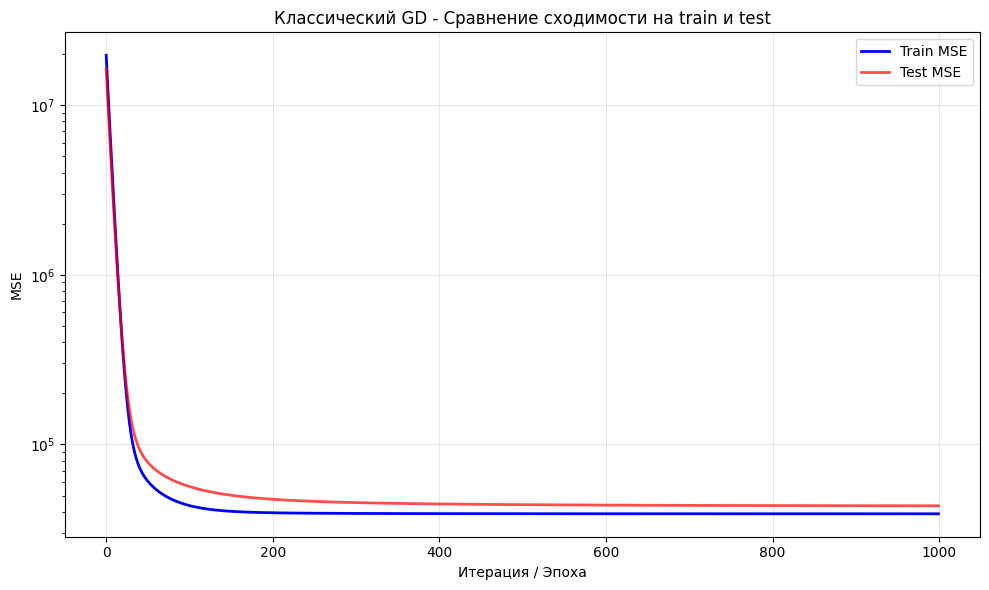

In [54]:
# Строим график сходимости
plot_method_comparison(tr_losses, tst_losses, 'Классический GD')

Модель на всех признаках без регуляризации показывает признаки неустойчивости:

- Наблюдается переобучение (на это указывает то, что кривая test выше train на графике сходимости);

- Признак `organic_carbon`, имеющий сильную корреляцию с таргетом (0.63), получил вес близкий к нулю (2.50), в то время как слабо коррелированный `brittleness` (0.27) получил большой вес (365.15). Модель не может корректно распределить влияние между взаимосвязанными признаками.

- Вес `acoustic_impedance` изменился с положительного (в модели без скоррелированных признаков) на отрицательный.

Таким образом, при наличии мультиколлинеарных признаков модель не справляется с корректной интерпретацией их значимости и демонстрирует неустойчивость. Хорошие показатели по метрикам MAPE и $R^2$ обманчивы и на самом деле за ними стоит переобучение, что подтверждается графиком сходимости.

Попробуем оценить поведение модели при применении L1 и L2 регуляризации для устранения мультиколинеарности.

L1-регуляризация добавляет к функции потерь сумму модулей коэффициентов:

$$L1(a) = MSE + \lambda \sum_{k=1}^{n} |a_k|$$

L2-регуляризация добавляет к функции потерь суммы квадратов коэффициентов, умноженных на коэффициент регуляризации:

$$L2(a) = MSE + \lambda * \sum_{k=1}^{n} a_k^2$$

Параметр $\lambda$ (alpha) регулирует силу штрафа: большое значение обнуляет ненужные коэффициенты, уменьшая сложность модели и риск переобучения. При $\lambda=0$ это обычная линейная регрессия.

Как мы уже выяснили при наличии мультиколинеарных признаков модель может демонстрировать обманчиво высокий $R^2$ и низкий $MAPE$, что на самом деле является признаком переобучения (это подвтерждается графиком сходимости, где кривая `test` находится выше, чем `train`).

Поэтому при выборе оптимального параметра `lambda` нельзя опираться только на $R^2$. При самом наилучшем $R^2$ сила регуляризации может оказаться недостататочно сильной и не сгладит влияние мультиколинеарных признаков.

Поэтому необходимо выбрать такое значение `lambda`, чтобы регуляризация была достаточной, но при этом предсказательная способность модели оставалась на достаточно высоком уровне.

Для этого можно использовать правило одной стандартной ошибки (`1-SE rule`) — это метод выбора модели в машинном обучении и статистике, рекомендующий предпочесть оптимальную модель (в нашем случае с наивысшим допустим значением `lamda`, чья производительность (в нашем случае $R^2$) находится в пределах одной стандартной ошибки (SE) от наилучшей модели (с наивысшим $R^2$).

In [55]:
def l1_reg(weights, lambda_val=0.01):
    """
    Вычисляет градиент L1-регуляризации (Lasso).

    Параметры:
        weights (np.array): Вектор весов модели (первый элемент - bias)
        lambda_val (float): Коэффициент регуляризации.
                            По умолчанию: 0.01

    Возвращает:
        np.array: Градиент L1-регуляризации для каждого веса
                 (для bias градиент = 0)
    """
    # Создаем массив для градиента
    grad_l1 = np.zeros_like(weights)

    # Применяем регуляризацию ко всем весам, кроме bias
    grad_l1[1:] = lambda_val * np.sign(weights[1:])

    return grad_l1

In [56]:
def l2_reg(weights, lambda_val=0.01):
    """
    Вычисляет градиент L2-регуляризации (Ridge).

    Параметры:
        weights (np.array): Вектор весов модели (первый элемент - bias)
        lambda_val (float): Коэффициент регуляризации.
                            По умолчанию: 0.01

    Возвращает:
        np.array: Градиент L2-регуляризации для каждого веса
                 (для bias градиент = 0)
    """
    # Создаем массив для градиента
    grad_l2 = np.zeros_like(weights)

    # Применяем регуляризацию ко всем весам, кроме bias
    grad_l2[1:] = 2 * lambda_val * weights[1:]

    return grad_l2

In [57]:
def gradient_descent_with_reg(
    X_train, y_train, X_test, y_test,
    lr=0.1, n_iter=1000, l1=True, l2=False,
    lambda_val=0.01, calc_metrics=True,
    print_metrics=True
):
    """
    Реализует алгоритм градиентного спуска с регуляризацией.

    Параметры:
    X_train, y_train, X_test, y_test:
        Стандартные параметры
    lr (float):
        Скорость обучения
    n_iter (int):
        Количество итераций
    l1 (bool):
        L1-регуляризация. По умолчанию: True
    l2 (bool):
        L2-регуляризация. По умолчанию: False
    lambda_val (float):
        Коэффициент регуляризации. По умолчанию: 0.01
    calc_metrics (bool):
        Расчет MSE, R^2. По умолчанию: True
    print_metrics (bool):
        Вывод промежуточных результатов. По умолчанию: True
    """
    np.random.seed(42)

    n_samples, n_features = X_train.shape

    # Задаем начальное приближение вектора весов
    weights = np.random.randn(n_features) * 0.01
    train_losses = []
    test_losses = []
    train_scores = []
    test_scores = []

    for i in range(n_iter):
        # Предсказание на обучающей выборке
        y_train_pred = predict(X_train, weights)

        # Рассчитываем остатки
        error = y_train_pred - y_train

        # Градиент от MSE
        grad_mse = (2 / n_samples) * np.dot(X_train.T, error)

        if l1:
            # Применяем L1-регуляризацию
            grad_reg = l1_reg(weights, lambda_val)
        elif l2:
            # Применяем L2-регуляризацию
            grad_reg = l2_reg(weights, lambda_val)
        else:
            grad_reg = 0

        # Полный градиент
        grad = grad_mse + grad_reg

        # Обновляем веса
        weights = weights - lr * grad

        # Рассчитываем метрики
        if calc_metrics:
            # Метрики на train
            train_loss = mse_loss(y_train, y_train_pred)
            train_r2 = metrics.r2_score(y_train, y_train_pred)

            # Метрики на test
            y_test_pred = predict(X_test, weights)
            test_loss = mse_loss(y_test, y_test_pred)
            test_r2 = metrics.r2_score(y_test, y_test_pred)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_scores.append(train_r2)
            test_scores.append(test_r2)

            if print_metrics and i % 100 == 0:
                print(f"Итерация {i+1}: Train MSE={train_loss:.2f}, Test MSE={test_loss:.2f}")
                print(f"Ненулевых весов: {np.sum(np.abs(weights[1:]) > 1e-6)}/{n_features-1}")

    return weights, train_losses, test_losses, train_scores, test_scores

In [58]:
def find_best_lambda_param(
    X_train, y_train, X_test, y_test,
    lr=0.1, n_iter=1000,
    lambda_values=np.logspace(-4, 1, 20),
    l1=True, l2=False
):
    """
    Подбирает оптимальный параметр lambda для L1 или L2 регуляризации.

    Параметры:
        X_train, y_train, X_test, y_test:
            Стандартные параметры
        lr (float):
            Скорость обучения
        n_iter (int):
            Количество итераций
        l1 (bool):
            L1-регуляризация. По умолчанию: True
        l2 (bool):
            L2-регуляризация. По умолчанию: False
        lambda_values (np.array):
            Массив с коэффициентами регуляризации
            По умолчанию: от 0.0001 до 10

    Возвращает:
        chosen_lambda: оптимальное значение lambda (по правилу 1 std)
        chosen_weights: веса лучшей модели (с оптимальным lambda)
        results_df: DataFrame с результатами для всех lambda
    """
    if l1 and l2:
        raise ValueError("Выберите что-то одно: L1 или L2 регуляризацию")

    reg_type = "L1" if l1 else "L2"
    print(f"{'-'*60}")
    print(f"Подбор оптимального lambda для {reg_type}-регуляризации")
    print(f"{'-'*60}")

    results = []

    for val in lambda_values:
        try:
            # Обучаем модель
            weights, *_ = gradient_descent_with_reg(
                X_train, y_train, X_test, y_test,
                lr=lr, n_iter=n_iter, l1=l1, l2=l2,
                lambda_val=val, calc_metrics=False,
                print_metrics=False
            )

            # Проверяем веса на NaN/inf
            if np.any(np.isnan(weights)) or np.any(np.isinf(weights)):
                print(f"lambda={val:.6f}: веса содержат NaN/inf")
                continue

            # Делаем предсказания
            y_train_pred = predict(X_train, weights)
            y_test_pred = predict(X_test, weights)

            # Проверяем предсказания на NaN/inf
            if np.any(np.isnan(y_train_pred)) or np.any(np.isinf(y_train_pred)) or \
               np.any(np.isnan(y_test_pred)) or np.any(np.isinf(y_test_pred)):
                print(f"lambda={val:.6f}: предсказания содержат NaN/inf")
                continue

            # Считаем метрики
            train_r2 = metrics.r2_score(y_train, y_train_pred)
            test_r2 = metrics.r2_score(y_test, y_test_pred)

            # Проверяем метрики на корректность
            if np.isnan(train_r2) or np.isinf(train_r2) or \
               np.isnan(test_r2) or np.isinf(test_r2):
                print(f"lambda={val:.6f}: метрики содержат NaN/inf")
                continue

            # Считаем количество ненулевых весов
            n_nonzero = np.sum(np.abs(weights[1:]) > 1e-6)

            # Сохраняем результаты
            results.append({
                'lambda': val,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'n_nonzero': n_nonzero,
                'weights': weights
            })

            print(f"lambda={val:.6f}: Train R^2={train_r2:.4f}, Test R^2={test_r2:.4f}, "
                  f"Ненулевых признаков={n_nonzero}/{len(weights)-1}")

        except Exception as e:
            print(f"lambda={val:.6f}: Ошибка - {str(e)[:50]}...")
            continue

    # Проверяем, есть ли успешные результаты
    if len(results) == 0:
        raise ValueError("Нет успешных результатов. Необходим меньший диапазон lambda.")

    # Создаем DataFrame с результатами
    results_df = pd.DataFrame(results)

    # Применяем правило одной стандартной ошибки
    best_r2 = results_df['test_r2'].max()
    best_std = results_df['test_r2'].std()

    # Находим кандидатов: модели, у которых R^2 не хуже best - std
    candidates = results_df[results_df['test_r2'] >= best_r2 - best_std]

    # Проверяем, есть ли кандидаты
    if len(candidates) == 0:
        print("Нет кандидатов по правилу 1 std. Используем лучшее lambda.")
        chosen_lambda = results_df.loc[results_df['test_r2'].idxmax(), 'lambda']
    else:
        # Выбираем самое большое lambda среди кандидатов
        chosen_lambda = candidates['lambda'].max()

    # Получаем веса для выбранного lambda
    chosen_row = results_df[results_df['lambda'] == chosen_lambda]

    # Проверяем, что нашли строку
    if len(chosen_row) == 0:
        # Если не нашли точное совпадение, берем ближайшее
        idx = (results_df['lambda'] - chosen_lambda).abs().idxmin()
        chosen_row = results_df.loc[[idx]]
        chosen_lambda = chosen_row['lambda'].iloc[0]

    chosen_weights = chosen_row['weights'].iloc[0]
    chosen_r2 = chosen_row['test_r2'].iloc[0]

    # Финальный вывод
    print(f"{'-'*60}")
    print(f"Лучший Test R^2: {best_r2:.4f}")
    print(f"Стандартное отклонение: {best_std:.4f}")
    print(f"Порог отсечения (best - std): {best_r2 - best_std:.4f}")
    print(f"Количество кандидатов: {len(candidates)}")
    if len(candidates) > 0:
        print(f"Диапазон lambda кандидатов: {candidates['lambda'].min():.6f} - {candidates['lambda'].max():.6f}")
    print(f"{'-'*60}")
    print(f"Оптимальное lambda: {chosen_lambda:.6f}")
    print(f"Test R^2 при оптимальном lambda: {chosen_r2:.4f}")
    print(f"Оптимальные веса: {chosen_weights}")
    print(f"{'-'*60}")

    return chosen_lambda, chosen_weights, results_df

In [59]:
# Подбираем оптимальное значение lambda для L1-регуляризации
lasso_lambda, lasso_weights, lasso_df = find_best_lambda_param(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=0.1, n_iter=1000,
    lambda_values=np.logspace(-4, 1, 20),
    l1=True, l2=False
)

------------------------------------------------------------
Подбор оптимального lambda для L1-регуляризации
------------------------------------------------------------
lambda=0.000100: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.000183: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.000336: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.000616: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.001129: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.002069: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.003793: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.006952: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.012743: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.023357: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.042813: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признако

In [60]:
# Подбираем оптимальное значение lambda для L2-регуляризации
ridge_lambda, ridge_weights, ridge_df = find_best_lambda_param(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=0.1, n_iter=1000,
    lambda_values=np.logspace(-4, 1, 10),
    l1=False, l2=True
)

------------------------------------------------------------
Подбор оптимального lambda для L2-регуляризации
------------------------------------------------------------
lambda=0.000100: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.000359: Train R^2=0.9586, Test R^2=0.9545, Ненулевых признаков=6/6
lambda=0.001292: Train R^2=0.9586, Test R^2=0.9543, Ненулевых признаков=6/6
lambda=0.004642: Train R^2=0.9586, Test R^2=0.9538, Ненулевых признаков=6/6
lambda=0.016681: Train R^2=0.9583, Test R^2=0.9519, Ненулевых признаков=6/6
lambda=0.059948: Train R^2=0.9555, Test R^2=0.9462, Ненулевых признаков=6/6
lambda=0.215443: Train R^2=0.9359, Test R^2=0.9243, Ненулевых признаков=6/6
lambda=0.774264: Train R^2=0.8375, Test R^2=0.8276, Ненулевых признаков=6/6
lambda=2.782559: Train R^2=0.5720, Test R^2=0.5638, Ненулевых признаков=6/6
lambda=10.000000: метрики содержат NaN/inf
------------------------------------------------------------
Лучший Test R^2: 0.9545
Стандартное отклон

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)


В результате подбора наилучшим значением $\lambda$ оказалось 0.0001. Это справедливо как для L1, так и для L2 регуляризации. Однако при заданном значении `lambda` регуляризация будет недостаточно сильной, из-за чего мулькилонеарность признаков не будет нивелирована.

Таким образом, были подобраны оптимальные значение `lambda`, при которых регуляризация будет достаточно сильной, и при этом сохранится высокая предсказательная способность модели (в пределах одного стандартного отклонения от лучшего $R^2$
).

Оцением основные метрки по моделям, обученным с L1 и L2 регуляризацией при оптимальном $\lambda$ и сравним полученные результаты с теми, которые были получены при обучении на выборках без мультиколинеарных признаков.

In [61]:
# Обучаем гр. спуск с L1 рег. при оптимальном lambda
lasso_weights, lasso_train_losses, lasso_test_losses, lasso_train_scores, lasso_test_scores = gradient_descent_with_reg(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_iter=params['n_iter'], l1=True, l2=False,
    lambda_val=lasso_lambda, calc_metrics=True,
    print_metrics=False
)

In [62]:
# Обучаем гр. спуск с L2 рег. при оптимальном lambda
ridge_weights, ridge_train_losses, ridge_test_losses, ridge_train_scores, ridge_test_scores = gradient_descent_with_reg(
    X_train_matrix, y_train, X_test_matrix, y_test,
    lr=params['lr'], n_iter=params['n_iter'], l1=False, l2=True,
    lambda_val=ridge_lambda, calc_metrics=True,
    print_metrics=False
)

In [63]:
# L1
lasso_train = predict(X_train_matrix, lasso_weights)
lasso_test = predict(X_test_matrix, lasso_weights)

# L2
ridge_train = predict(X_train_matrix, ridge_weights)
ridge_test = predict(X_test_matrix, ridge_weights)

lasso_tr_df = evaluate_regression(y_train, lasso_train)
lasso_tst_df = evaluate_regression(y_test, lasso_test)

print("MSE, MAE, MAPE, R^2 при применении L1-рег.")
print("Для train:")
display(lasso_tr_df)

print()
print("Для test:")
display(lasso_tst_df)
print('-' * 60)

ridge_tr_df = evaluate_regression(y_train, ridge_train)
ridge_tst_df = evaluate_regression(y_test, ridge_test)

print("MSE, MAE, MAPE, R^2 при применении L2-рег.")
print("Для train:")
display(ridge_tr_df)

print()
print("Для test:")
display(ridge_tst_df)

MSE, MAE, MAPE, R^2 при применении L1-рег.
Для train:


,MSE,MAE,MAPE,R^2
0,39053.11,156.92,0.04,0.9586



Для test:


,MSE,MAE,MAPE,R^2
0,43784.47,153.22,0.03,0.9541


------------------------------------------------------------
MSE, MAE, MAPE, R^2 при применении L2-рег.
Для train:


,MSE,MAE,MAPE,R^2
0,153334.30,315.22,0.08,0.8375



Для test:


,MSE,MAE,MAPE,R^2
0,164594.27,319.56,0.07,0.8276


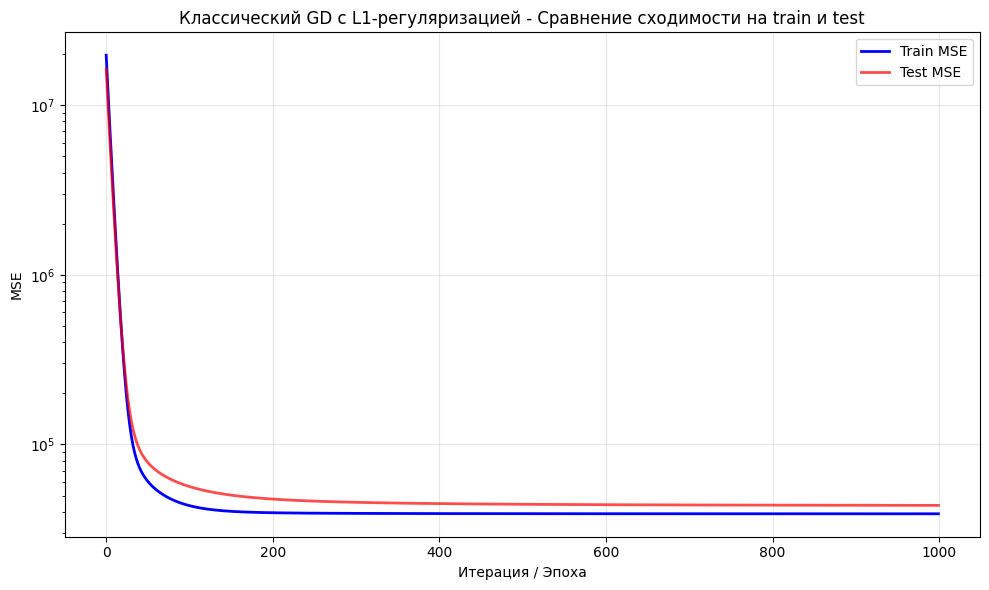

In [64]:
# Строим график сходимости для L1
plot_method_comparison(lasso_train_losses, lasso_test_losses, 'Классический GD с L1-регуляризацией')

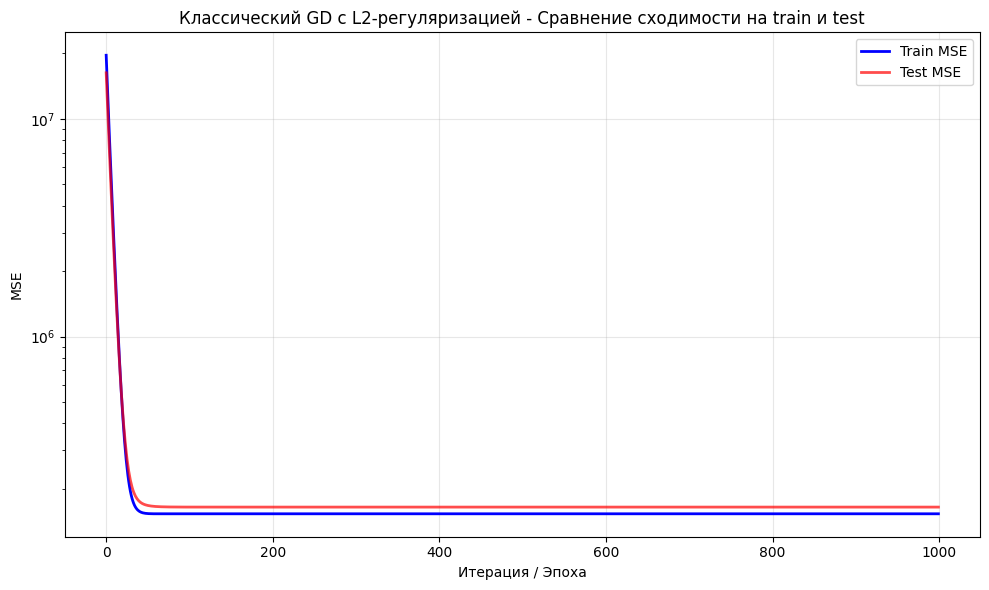

In [65]:
# Строим график сходимости для L2
plot_method_comparison(ridge_train_losses, ridge_test_losses, 'Классический GD с L2-регуляризацией')

Графики сходимости по-прежнему указывают на наличие переобучения, даже после применения регуляризации. При примении L2 регуляризации удалось сократить разрыв между `train` и `test`, однако кривая `test` все еще возвышается над `train`. Кроме того для сокращения влияние мультиколинеарных признаков при применении L2 был сделан компромисс в пользу снижения $R^2$ (0.83 на `test`). Также выросло значение $MAPE$, что указывает на то, что модель стала менее точной в своих предсказаниях.

**Вывод:**

1. **Удаление признаков (из Задания 4)** показало наилучший результат:
   - Test $R^2$ = 0.9565 (выше, чем у L1 и L2);
   - Нет переобучения (`test` даже лучше `train`).

2. **L1-регуляризация**:
   - Сохранила все признаки (не обнулила ни один);
   - Качество чуть ниже удаления признаков ($R^2$ 0.9541 против 0.9565);
   - Переобучение осталось.

3. **L2-регуляризация**:
   - Снизила качество ($R^2$=0.8276)
   - Не смогла полностью устранить переобучение
   - Слишком жесткий штраф для этих данных

**Итоговая рекомендация:** Для данного датасета оптимальной стратегией является
превентивное удаление мультиколлинеарных признаков. Это дает лучшее качество
и простую интерпретацию. Регуляризация, хотя и позволяет сохранить все признаки, не дает выигрыша в качестве и усложняет интерпретацию модели.

При прогнозировании стоит применять следующий набор призанков:

1. `porosity` (пористость);
2. `acoustic_impedance` (акустический импеданс);
3. `brittleness` (хрупкость);
4. `vitrinite_reflectance` (отражение витринита).

Удалить следует следующие признаки:

- `permeability` (проницаемость) — слишком коррелирует с porosity (`r`=0.76)
- `organic_carbon` (органический углерод) — коррелирует с porosity (`r`=0.69).

## Решение при помощи RMSprop

Реализуем алгоритм RMSprop на базе алгоритма Adagrad.

**AdaGrad (Adaptive Gradient)** — метод градиентного спуска с адаптивным шагом обучения для каждого параметра.

### Идея
- Каждый параметр получает **свой learning rate**
- Параметры, по которым градиенты большие и частые => шаг уменьшается
- Параметры с редкими обновлениями => шаг остаётся большим  
  (полезно для разреженных признаков)

### Обозначения
- $g_k = \nabla_a L(a_k; x_i, y_i) $ — градиент на шаге $k$
- $ G_k $ — накопленная сумма квадратов градиентов
- $ lr $ — базовый шаг обучения
- $ \epsilon $ — маленькая константа для численной устойчивости
- $ \odot $ — покомпонентное умножение

### Формулы
$$
G_k = G_{k-1} + g_k \odot g_k
$$

$$
a_{k+1} = a_k - \frac{lr}{\sqrt{G_k} + \epsilon} \odot g_k
$$

### Особенности
- learning rate **монотонно убывает**
- хорошо работает для NLP и разреженных данных
- может **слишком рано "затормозить" обучение**

### Недостаток
- из-за накопления $G_k$ шаг обучения может стать слишком маленьким  
  => модель перестаёт учиться


**RMSprop (Root Mean Square Propagation)** — улучшение Adagrad
### Идея
- Решает проблему затухания шага в Adagrad
- Использует экспоненциальное скользящее среднее вместо суммы всех градиентов
- "Забывает" старые градиенты, фокусируется на недавних

### Обозначения:

- $g_t$ — градиент на шаге $t$;

- $v_t$ — экспоненциальное среднее квадратов градиентов;

- $\beta$ — коэффициент затухания (гиперпараметр);

- $\eta$ — базовый шаг обучения (learning rate, гиперпараметр);

- $\varepsilon$ — маленькая константа для численной устойчивости;

- $\odot$ — покомпонентное умножение.

$$
\begin{cases}
v_t = \beta v_{t-1} + (1 - \beta) \cdot g_t \odot g_t \\[1em]
a_{t+1} = a_t - \dfrac{\eta}{\sqrt{v_t} + \varepsilon} \odot g_t
\end{cases}
$$


In [66]:
def rmsprop(
    X, y, lr=0.5, n_iter=1000, beta=0.9, epsilon=1e-6, calc_loss=True, print_loss=False,
    tolerance=1e-6, patience=10
):
    """
    RMSprop оптимизатор с ранней остановкой

    Параметры:
        X: Матрица признаков
        y: Целевая переменная
        lr: learning rate
        n_iter: Максимальное количество итераций
        beta: Коэффициент затухания (по умолчанию 0.9)
        epsilon: Маленькая константа для численной стабильности
        calc_loss: Вычислять loss
        print_loss: Выводить промежуточные значения
        tolerance: Минимальное улучшение для сброса счетчика
        patience: Терпение для ранней остановки
    """
    np.random.seed(42)

    n_samples, n_features = X.shape
    weights = np.random.randn(n_features) * 0.01
    v_t = np.zeros(n_features)  # Экспоненциальное среднее квадратов градиентов
    losses = []

    best_loss = float('inf')
    no_improve_count = 0

    for i in range(n_iter):
        # Полная предсказательная ошибка
        y_pred = predict(X, weights)
        error = y_pred - y
        grad = (2 / n_samples) * np.dot(X.T, error)

        # Обновление экспоненциального среднего квадратов градиентов
        v_t = beta * v_t + (1 - beta) * grad ** 2

        # Масштабирование градиента
        adjusted_grad = grad / (np.sqrt(v_t) + epsilon)
        weights -= lr * adjusted_grad

        # Loss
        if calc_loss:
            loss = mse_loss(y, y_pred)
            losses.append(loss)

            # Промежуточные выводы на экран
            if print_loss and i % 10 == 0:
                print(f"Итерация {i+1}: MSE = {loss:.4f}")

            # Проверка на раннюю остановку
            if best_loss - loss > tolerance:
                best_loss = loss
                no_improve_count = 0
            else:
                no_improve_count += 1

            if no_improve_count >= patience:
                print(f"Ранняя остановка на {i+1} итерации.")
                break

    return weights, losses

Вновь создадим `train` и `test` выборки без мультиколинеарных признаков.

In [67]:
# Разделяем на X и y
X = well_df.copy().drop(columns='extr_per_day')
y = well_df['extr_per_day'].copy()

# Разделяем на train/test
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

Применим машстабирование к признакам:

- `StandardScaler` для `porosity` и `brittleness`;
- `RobustScaler` для `acoustic_impedance` и `vitrinite_reflectance`.

Также осуществим масштабирование таргета, поскольку алгоритм RMSprop чуствителен к масштабу таргета и признаков.

Также создадим единичный столбец для применения аналитического решения.

In [68]:
# StandardScaler
st_scaler = preprocessing.StandardScaler()

cols_to_st = ['porosity', 'brittleness']

X_train_st_scaled = st_scaler.fit_transform(X_train[cols_to_st])
X_test_st_scaled = st_scaler.transform(X_test[cols_to_st])

# Масштабирование целевой переменной
y_scaler = preprocessing.StandardScaler()

y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

# RobustScaler
rb_scaler = preprocessing.RobustScaler()

cols_to_rb = ['acoustic_impedance', 'vitrinite_reflectance']

X_train_rb_scaled = rb_scaler.fit_transform(X_train[cols_to_rb])
X_test_rb_scaled = rb_scaler.transform(X_test[cols_to_rb])

In [69]:
# Создаем единичный столбец
X_train_ones_vector = np.ones((X_train.shape[0], 1))

X_test_ones_vector = np.ones((X_test.shape[0], 1))

In [70]:
# Объединяем
X_train_matrix = np.column_stack([
    X_train_ones_vector,
    X_train_st_scaled,
    X_train_rb_scaled
])

X_test_matrix = np.column_stack([
    X_test_ones_vector,
    X_test_st_scaled,
    X_test_rb_scaled
])

Применим RMSprop.

In [71]:
# Обучаем алгоритм
rms_weights, losses = rmsprop(
    X_train_matrix, y_train, lr=0.01, n_iter=1000, beta=0.9, epsilon=1e-8, calc_loss=True, print_loss=False,
    tolerance=1e-4, patience=10
)

Ранняя остановка на 132 итерации.


In [72]:
# Делаем предсказание
rms_tr_pred = predict(X_train_matrix, rms_weights)
rms_test_pred = predict(X_test_matrix, rms_weights)

# Обратное масштабирование
y_train = y_scaler.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_test = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

rms_tr_pred = y_scaler.inverse_transform(rms_tr_pred.reshape(-1, 1)).ravel()
rms_tst_pred = y_scaler.inverse_transform(rms_test_pred.reshape(-1, 1)).ravel()

In [73]:
# Оцениваем метрики
print("MSE, MAE, MAPE, R^2 для RMSprop.")
print("Для train:")
display(evaluate_regression(rms_tr_pred, y_train))

print()
print("Для test:")
display(evaluate_regression(rms_tst_pred, y_test))

MSE, MAE, MAPE, R^2 для RMSprop.
Для train:


,MSE,MAE,MAPE,R^2
0,57220.94,181.37,0.04,0.9356



Для test:


,MSE,MAE,MAPE,R^2
0,40484.94,131.24,0.03,0.9531


## Вывод
В результате проведенного исследования были реализованы и сравнены различные методы оптимизации для задачи линейной регрессии:

1. Классический градиентный спуск показал высокое качество ($R^2$ = 0.9565),
   достигнув решения, близкого к аналитическому МНК.

2. L1-регуляризация (Lasso) позволила сохранить все признаки,
   но незначительно снизила качество на тесте ($R^2$ = 0.9541).

3. L2-регуляризация (Ridge) привела к существенному падению качества ($R^2$ = 0.8276)

При этом как при L1 регуляризации, так и при L2-регуляризации не удалось подобрать оптимальное значение  $\lambda$ для устранения мультиколлинеарности при сохранении достаточно высокого $R^2$.

4. **RMSprop с оптимальными гиперпараметрами (lr = 0.01, $\beta$ = 0.9, $\epsilon$ = 1e-8)
   показал хороший результат на тестовой выборке:** $R^2$ = 0.9531(сопоставим с классическим GD)

Таким образом, при правильном подборе гиперпараметров адаптивные методы оптимизации, такие как RMSprop, могут успешно конкурировать с классическими подходами и достигать нужной сходимости за гораздо меньшее количество итераций.